In [1]:
# =============================================================================
# Image Feature EDA for Amazon Product BSR Classification
# =============================================================================
# This notebook explores the relationship between image features (extracted
# from the image_feature_extraction.ipynb pipeline) and BINARY CLASSIFICATION targets:
#
# TARGET 1: Has Main BSR - Whether product has a main BSR rank (binary: 0 or 1)
#           0 = No main BSR rank, 1 = Has main BSR rank
#
# TARGET 2: Has Lowest BSR - Whether product has any BSR rank (binary: 0 or 1)
#           0 = No BSR rank in any category, 1 = Has BSR rank
#
# Feature Groups from image_feature_extraction.ipynb:
# - Quality Features: brightness, contrast, saturation, colorfulness, sharpness, blur, entropy
# - Composition Features: edge_density, bg_uniformity, white_bg_pct, saliency, object_occupancy
# - OCR Features: text detection, word counts, claims detection
# - Object Detection Features: detected objects, bounding boxes, person/face detection
# - Embeddings: CNN (EfficientNet) and CLIP embeddings, compressed via PCA to 128 dimensions
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Plotting settings
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

# Color palettes for distinguishing between two classes
CLASS_0_COLOR = '#E74C3C'      # Red for No BSR (class 0)
CLASS_1_COLOR = '#27AE60'      # Green for Has BSR (class 1)
PALETTE_BINARY = [CLASS_0_COLOR, CLASS_1_COLOR]

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [2]:
# =============================================================================
# 1. DATA LOADING AND OVERVIEW
# =============================================================================

# Load the dataset with image features
DATA_PATH = "../../data/products_with_image_feats.csv"
df = pd.read_csv(DATA_PATH)

print(f"Dataset shape: {df.shape}")
print(f"Total products: {len(df):,}")
print(f"Total columns: {len(df.columns):,}")

Dataset shape: (36879, 7652)
Total products: 36,879
Total columns: 7,652


In [3]:
# Define feature groups based on image_feature_extraction.ipynb
# Each group has mean, max, std aggregations + hero_ version for hero image

# Target columns - BINARY CLASSIFICATION
# has_main_bsr: 1 if product has main BSR rank, 0 otherwise
# has_lowest_bsr: 1 if product has lowest BSR rank, 0 otherwise
TARGET_COLS = {
    'has_main_bsr': 'Binary: whether product has main BSR rank',
    'has_lowest_bsr': 'Binary: whether product has any BSR rank'
}

# Quality Features (technical image quality)
QUALITY_BASE_FEATURES = [
    'width', 'height', 'aspect_ratio', 'filesize_kb',
    'brightness_mean', 'brightness_std', 'contrast',
    'saturation_mean', 'saturation_std', 'colorfulness',
    'sharpness_laplacian_var', 'blur_score', 'entropy',
    'exposure_clipped_high_pct', 'exposure_clipped_low_pct'
]

# Composition Features (visual composition and layout)
COMPOSITION_BASE_FEATURES = [
    'edge_density', 'bg_uniformity', 'white_bg_pct',
    'dominant_color_count', 'saliency_peak_ratio',
    'saliency_center_dist', 'object_occupancy_proxy', 'border_clutter_score'
]

# OCR Features (text detection)
OCR_BASE_FEATURES = [
    'ocr_char_count', 'ocr_word_count', 'ocr_num_count',
    'ocr_allcaps_ratio', 'ocr_has_units', 'ocr_has_claims',
    'text_overlay_area_proxy'
]

# Object Detection Features
DETECTION_BASE_FEATURES = [
    'det_num_objects', 'det_main_box_area_ratio', 'det_main_box_center_dist',
    'det_has_person', 'det_has_face', 'det_has_hand',
    'det_secondary_objects_count', 'det_conf_mean', 'det_conf_max'
]

# Helper function to get all aggregation columns for a base feature
def get_feature_cols(base_features, suffix='_mean'):
    """Get column names with given suffix for base features"""
    cols = []
    for feat in base_features:
        col = f"{feat}{suffix}"
        if col in df.columns:
            cols.append(col)
    return cols

# Get hero image columns
def get_hero_cols(base_features):
    """Get hero image columns for base features"""
    cols = []
    for feat in base_features:
        col = f"hero_{feat}"
        if col in df.columns:
            cols.append(col)
    return cols

print("Feature groups defined:")
print(f"  - Quality features: {len(QUALITY_BASE_FEATURES)} base features")
print(f"  - Composition features: {len(COMPOSITION_BASE_FEATURES)} base features")
print(f"  - OCR features: {len(OCR_BASE_FEATURES)} base features")
print(f"  - Detection features: {len(DETECTION_BASE_FEATURES)} base features")

Feature groups defined:
  - Quality features: 15 base features
  - Composition features: 8 base features
  - OCR features: 7 base features
  - Detection features: 9 base features


In [4]:
# Check for products with image features
df_with_images = df[df['num_images'].notna()].copy()
print(f"Products with image features: {len(df_with_images):,} ({len(df_with_images)/len(df)*100:.1f}%)")

# Create BINARY CLASSIFICATION targets
# has_main_bsr: 1 if product has main BSR rank, 0 otherwise
# has_lowest_bsr: 1 if product has lowest BSR rank, 0 otherwise
df_with_images['has_main_bsr'] = df_with_images['main_bsr_rank'].notna().astype(int)
df_with_images['has_lowest_bsr'] = df_with_images['lowest_bsr_rank'].notna().astype(int)

# Check class distribution
print("\n" + "="*60)
print("BINARY CLASSIFICATION TARGET DISTRIBUTION")
print("="*60)

print(f"\nTarget 1: has_main_bsr (Does product have main BSR rank?)")
main_class_counts = df_with_images['has_main_bsr'].value_counts().sort_index()
print(f"  - Class 0 (No BSR):  {main_class_counts[0]:,} products ({main_class_counts[0]/len(df_with_images)*100:.1f}%)")
print(f"  - Class 1 (Has BSR): {main_class_counts[1]:,} products ({main_class_counts[1]/len(df_with_images)*100:.1f}%)")

print(f"\nTarget 2: has_lowest_bsr (Does product have any BSR rank?)")
lowest_class_counts = df_with_images['has_lowest_bsr'].value_counts().sort_index()
print(f"  - Class 0 (No BSR):  {lowest_class_counts[0]:,} products ({lowest_class_counts[0]/len(df_with_images)*100:.1f}%)")
print(f"  - Class 1 (Has BSR): {lowest_class_counts[1]:,} products ({lowest_class_counts[1]/len(df_with_images)*100:.1f}%)")

# Use all products with image features for analysis (since we now have binary targets)
df_analysis = df_with_images.copy()
print(f"\nTotal products for classification analysis: {len(df_analysis):,}")

Products with image features: 36,879 (100.0%)

BINARY CLASSIFICATION TARGET DISTRIBUTION

Target 1: has_main_bsr (Does product have main BSR rank?)
  - Class 0 (No BSR):  11,113 products (30.1%)
  - Class 1 (Has BSR): 25,766 products (69.9%)

Target 2: has_lowest_bsr (Does product have any BSR rank?)
  - Class 0 (No BSR):  11,113 products (30.1%)
  - Class 1 (Has BSR): 25,766 products (69.9%)

Total products for classification analysis: 36,879


---
## 2. TARGET VARIABLE ANALYSIS (BINARY CLASSIFICATION)
We have two binary classification targets:
1. **Has Main BSR** (`has_main_bsr`): Whether the product has a main BSR rank (0 = No, 1 = Yes)
2. **Has Lowest BSR** (`has_lowest_bsr`): Whether the product has any BSR rank (0 = No, 1 = Yes)

Class 0 = Product does NOT have a BSR rank (not selling/tracked)
Class 1 = Product HAS a BSR rank (actively selling/tracked)

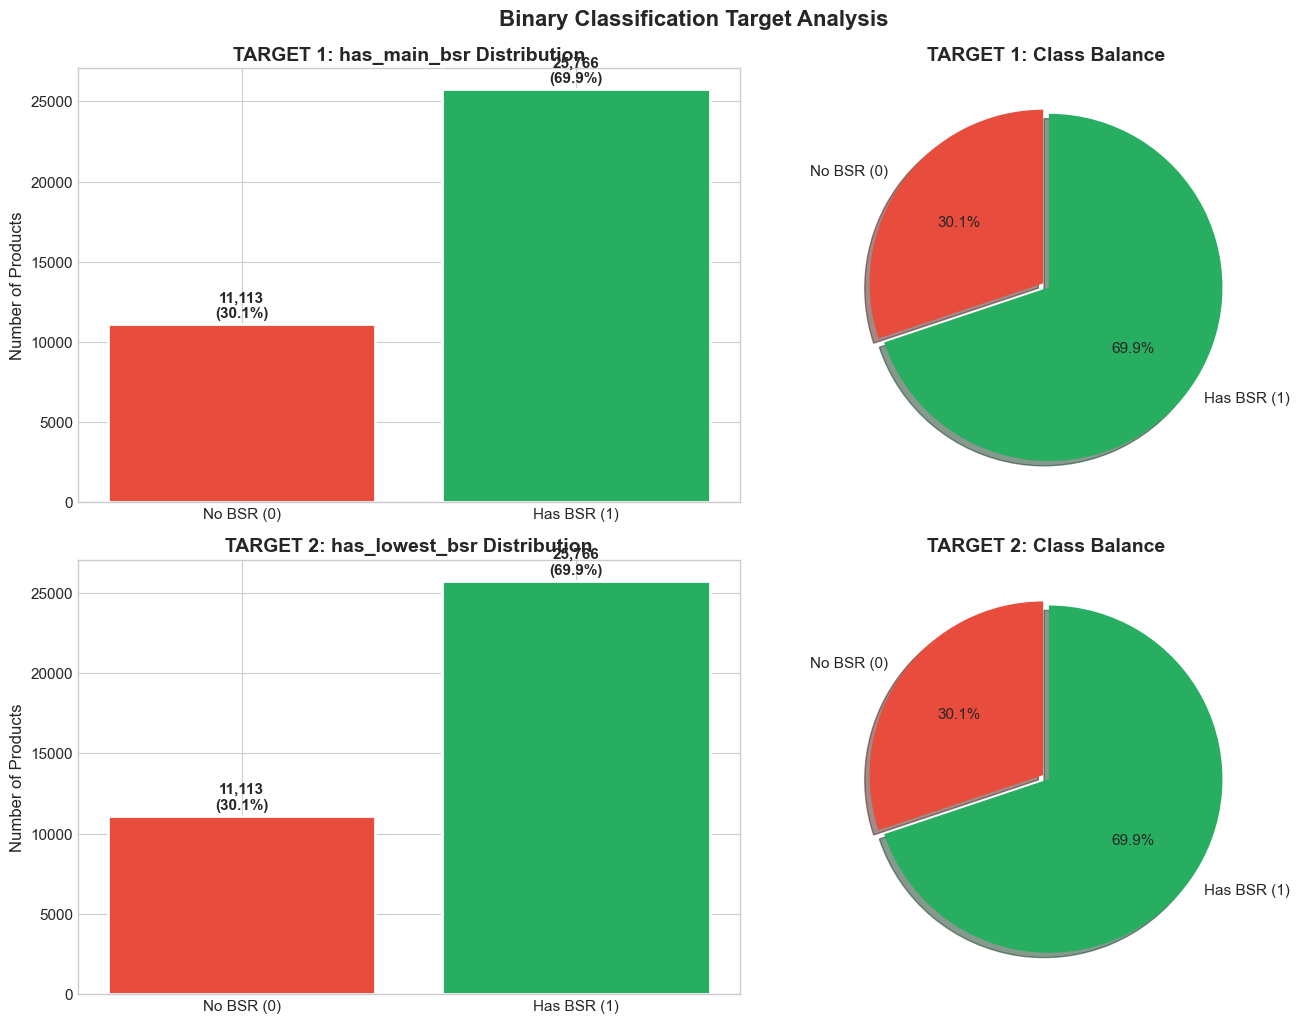


CLASSIFICATION TARGET STATISTICS

Target 1: has_main_bsr
  Class 0 (No BSR):  11,113 (30.1%)
  Class 1 (Has BSR): 25,766 (69.9%)
  Class imbalance ratio: 1:2.32

Target 2: has_lowest_bsr
  Class 0 (No BSR):  11,113 (30.1%)
  Class 1 (Has BSR): 25,766 (69.9%)
  Class imbalance ratio: 1:2.32

Targets identical: True


In [5]:
# Binary Classification Target Visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Target 1: has_main_bsr - Bar chart
ax1 = axes[0, 0]
main_counts = df_analysis['has_main_bsr'].value_counts().sort_index()
bars1 = ax1.bar(['No BSR (0)', 'Has BSR (1)'], main_counts.values, color=PALETTE_BINARY, edgecolor='white', linewidth=2)
ax1.set_ylabel('Number of Products')
ax1.set_title('TARGET 1: has_main_bsr Distribution', fontweight='bold')
for bar, count in zip(bars1, main_counts.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200, 
             f'{count:,}\n({count/len(df_analysis)*100:.1f}%)', 
             ha='center', va='bottom', fontsize=11, fontweight='bold')

# Target 1: Pie chart
ax2 = axes[0, 1]
ax2.pie(main_counts.values, labels=['No BSR (0)', 'Has BSR (1)'], 
        colors=PALETTE_BINARY, autopct='%1.1f%%', startangle=90,
        explode=(0.02, 0.02), shadow=True)
ax2.set_title('TARGET 1: Class Balance', fontweight='bold')

# Target 2: has_lowest_bsr - Bar chart
ax3 = axes[1, 0]
lowest_counts = df_analysis['has_lowest_bsr'].value_counts().sort_index()
bars2 = ax3.bar(['No BSR (0)', 'Has BSR (1)'], lowest_counts.values, color=PALETTE_BINARY, edgecolor='white', linewidth=2)
ax3.set_ylabel('Number of Products')
ax3.set_title('TARGET 2: has_lowest_bsr Distribution', fontweight='bold')
for bar, count in zip(bars2, lowest_counts.values):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200, 
             f'{count:,}\n({count/len(df_analysis)*100:.1f}%)', 
             ha='center', va='bottom', fontsize=11, fontweight='bold')

# Target 2: Pie chart
ax4 = axes[1, 1]
ax4.pie(lowest_counts.values, labels=['No BSR (0)', 'Has BSR (1)'], 
        colors=PALETTE_BINARY, autopct='%1.1f%%', startangle=90,
        explode=(0.02, 0.02), shadow=True)
ax4.set_title('TARGET 2: Class Balance', fontweight='bold')

plt.tight_layout()
plt.suptitle('Binary Classification Target Analysis', fontsize=16, fontweight='bold', y=1.02)
plt.show()

# Class balance statistics
print("\n" + "="*60)
print("CLASSIFICATION TARGET STATISTICS")
print("="*60)

print("\nTarget 1: has_main_bsr")
print(f"  Class 0 (No BSR):  {main_counts[0]:,} ({main_counts[0]/len(df_analysis)*100:.1f}%)")
print(f"  Class 1 (Has BSR): {main_counts[1]:,} ({main_counts[1]/len(df_analysis)*100:.1f}%)")
print(f"  Class imbalance ratio: 1:{main_counts[1]/main_counts[0]:.2f}")

print("\nTarget 2: has_lowest_bsr")
print(f"  Class 0 (No BSR):  {lowest_counts[0]:,} ({lowest_counts[0]/len(df_analysis)*100:.1f}%)")
print(f"  Class 1 (Has BSR): {lowest_counts[1]:,} ({lowest_counts[1]/len(df_analysis)*100:.1f}%)")
print(f"  Class imbalance ratio: 1:{lowest_counts[1]/lowest_counts[0]:.2f}")

# Check if targets are identical
targets_match = (df_analysis['has_main_bsr'] == df_analysis['has_lowest_bsr']).all()
print(f"\nTargets identical: {targets_match}")

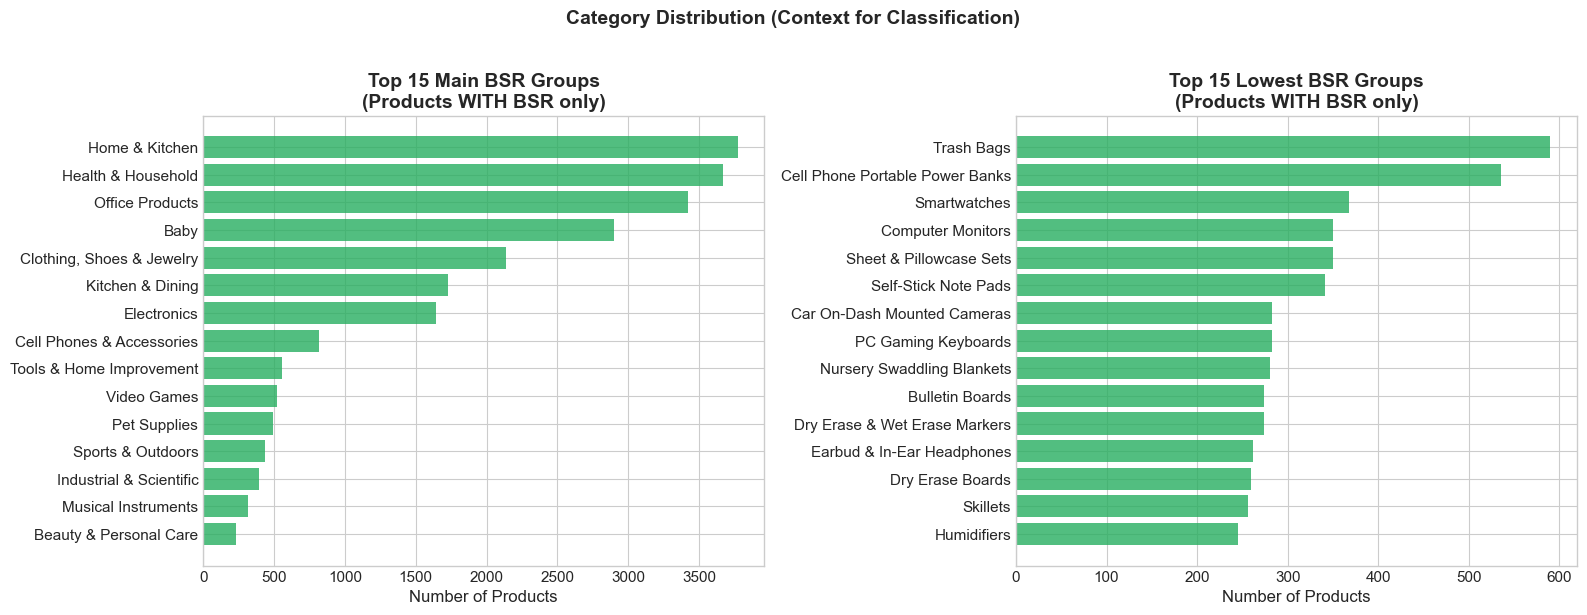


Products with main BSR: 25,766 (69.9%)
Unique Main BSR Groups: 142


In [6]:
# BSR Group Analysis - Contextual Information (for products that HAVE BSR)
# Note: This shows the category distribution only for products with BSR rankings

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Main BSR Groups (only for products with BSR)
ax1 = axes[0]
has_bsr_df = df_analysis[df_analysis['has_main_bsr'] == 1]
main_groups = has_bsr_df['main_bsr_group'].value_counts().head(15)
bars1 = ax1.barh(range(len(main_groups)), main_groups.values, color=CLASS_1_COLOR, alpha=0.8)
ax1.set_yticks(range(len(main_groups)))
ax1.set_yticklabels([str(g)[:40] + '...' if len(str(g)) > 40 else str(g) for g in main_groups.index])
ax1.set_xlabel('Number of Products')
ax1.set_title('Top 15 Main BSR Groups\n(Products WITH BSR only)', fontweight='bold')
ax1.invert_yaxis()

# Lowest BSR Groups (only for products with BSR)
ax2 = axes[1]
has_lowest_df = df_analysis[df_analysis['has_lowest_bsr'] == 1]
lowest_groups = has_lowest_df['lowest_bsr_group'].value_counts().head(15)
bars2 = ax2.barh(range(len(lowest_groups)), lowest_groups.values, color=CLASS_1_COLOR, alpha=0.8)
ax2.set_yticks(range(len(lowest_groups)))
ax2.set_yticklabels([str(g)[:40] + '...' if len(str(g)) > 40 else str(g) for g in lowest_groups.index])
ax2.set_xlabel('Number of Products')
ax2.set_title('Top 15 Lowest BSR Groups\n(Products WITH BSR only)', fontweight='bold')
ax2.invert_yaxis()

plt.suptitle('Category Distribution (Context for Classification)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"\nProducts with main BSR: {len(has_bsr_df):,} ({len(has_bsr_df)/len(df_analysis)*100:.1f}%)")
print(f"Unique Main BSR Groups: {has_bsr_df['main_bsr_group'].nunique()}")

---
## 3. IMAGE QUALITY FEATURES
From `image_feature_extraction.ipynb`: Technical quality metrics computed using OpenCV and scikit-image
- **Dimensions**: width, height, aspect_ratio, filesize_kb
- **Brightness/Contrast**: brightness_mean, brightness_std, contrast
- **Color**: saturation_mean, saturation_std, colorfulness
- **Sharpness/Blur**: sharpness_laplacian_var (Laplacian variance), blur_score
- **Entropy**: Information content measure
- **Exposure**: exposure_clipped_high_pct, exposure_clipped_low_pct (over/under-exposed pixels)

Quality Feature Columns (mean aggregation):
['width_mean', 'height_mean', 'aspect_ratio_mean', 'filesize_kb_mean', 'brightness_mean_mean', 'brightness_std_mean', 'contrast_mean', 'saturation_mean_mean', 'saturation_std_mean', 'colorfulness_mean', 'sharpness_laplacian_var_mean', 'blur_score_mean', 'entropy_mean', 'exposure_clipped_high_pct_mean', 'exposure_clipped_low_pct_mean']


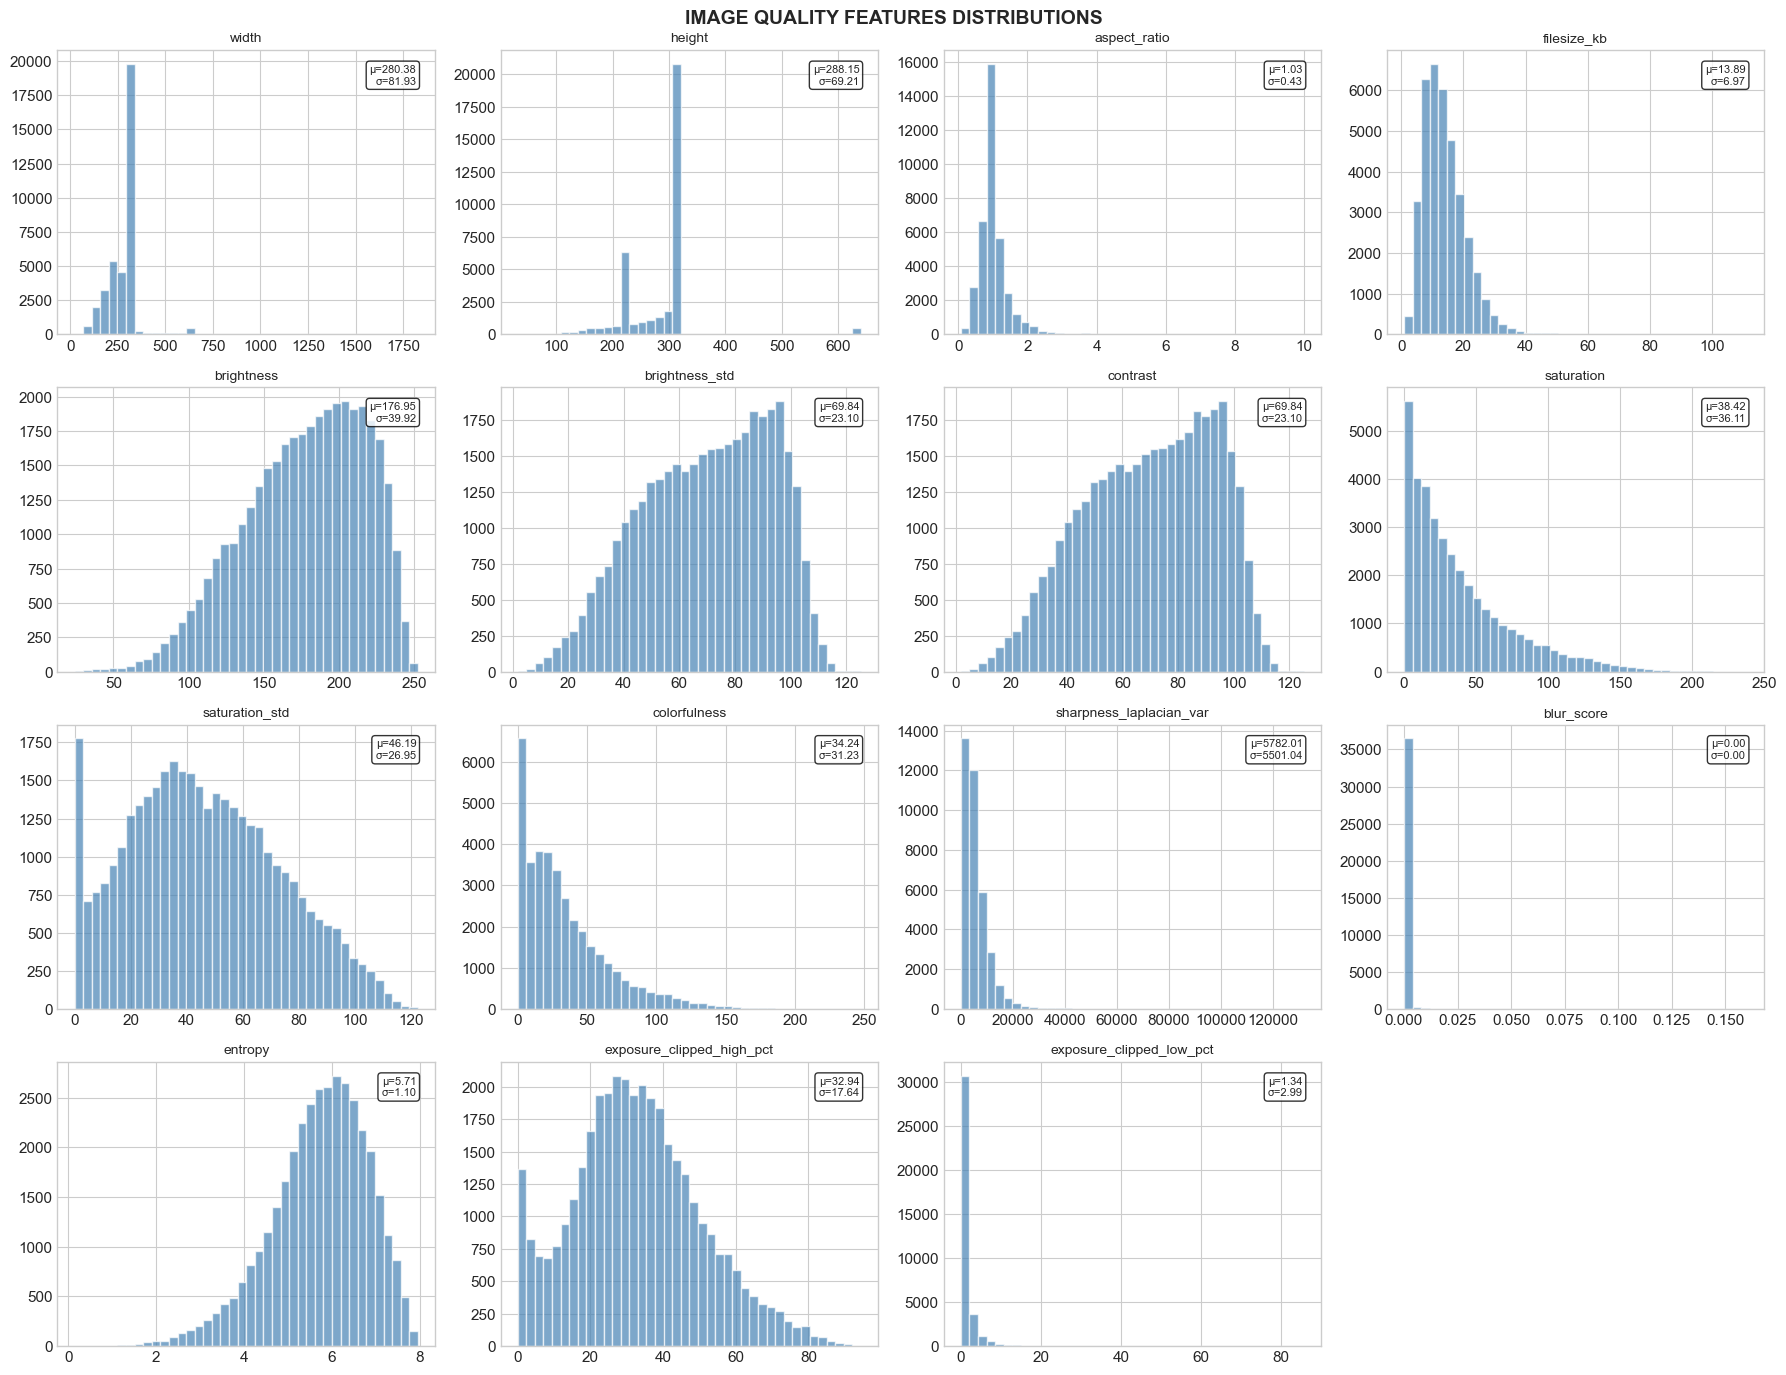

In [7]:
# Quality Features Distribution
quality_cols_mean = get_feature_cols(QUALITY_BASE_FEATURES, '_mean')
quality_cols_hero = get_hero_cols(QUALITY_BASE_FEATURES)

print("Quality Feature Columns (mean aggregation):")
print(quality_cols_mean)

# Create distribution plots for quality features
fig, axes = plt.subplots(4, 4, figsize=(18, 14))
axes = axes.flatten()

for idx, col in enumerate(quality_cols_mean[:16]):
    ax = axes[idx]
    data = df_analysis[col].dropna()
    ax.hist(data, bins=40, color='steelblue', alpha=0.7, edgecolor='white')
    ax.set_title(col.replace('_mean', ''), fontsize=10)
    ax.set_xlabel('')
    
    # Add statistics
    stats_text = f'μ={data.mean():.2f}\nσ={data.std():.2f}'
    ax.text(0.95, 0.95, stats_text, transform=ax.transAxes, fontsize=8,
            verticalalignment='top', horizontalalignment='right',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Hide unused subplots
for idx in range(len(quality_cols_mean), len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('IMAGE QUALITY FEATURES DISTRIBUTIONS', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

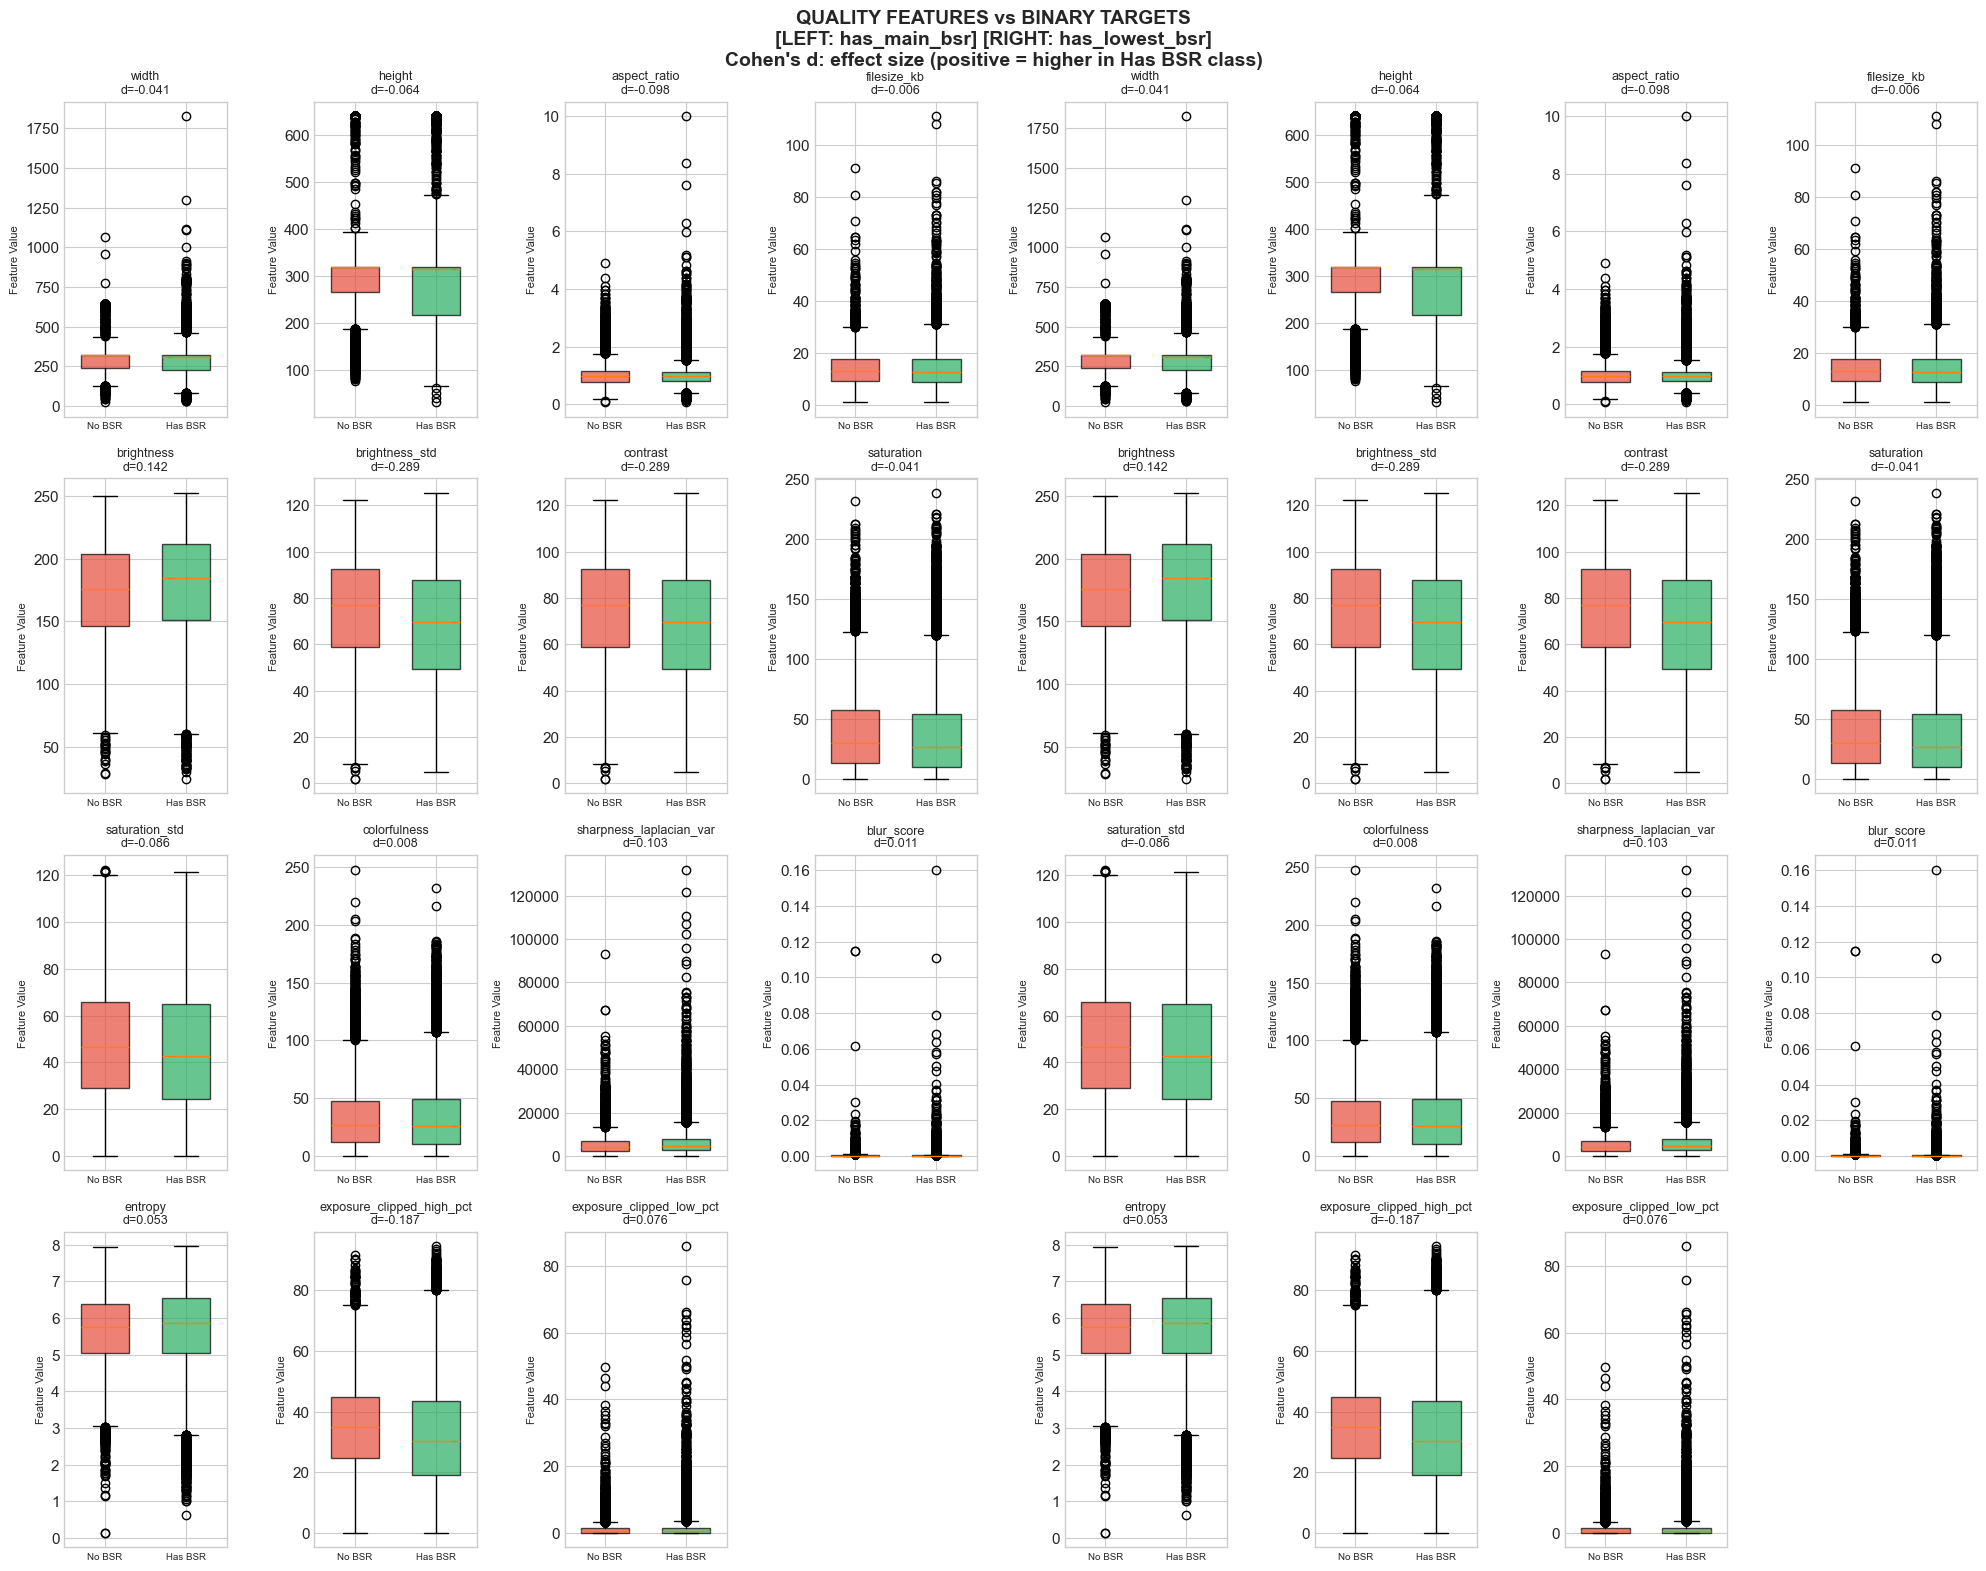

In [8]:
# Quality Features vs Binary Classification Targets - Box Plots by Class
def plot_feature_vs_targets(feature_cols, feature_name, n_cols=4):
    """Plot features against both binary classification targets using box plots"""
    n_features = len(feature_cols)
    n_rows = (n_features + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols * 2, figsize=(20, n_rows * 4))
    if n_rows == 1:
        axes = axes.reshape(1, -1)
    
    for idx, col in enumerate(feature_cols):
        row = idx // n_cols
        col_idx = idx % n_cols
        
        # has_main_bsr (left half) - Box plots by class
        ax1 = axes[row, col_idx]
        mask = df_analysis[col].notna()
        if mask.sum() > 0:
            data_class0 = df_analysis.loc[mask & (df_analysis['has_main_bsr'] == 0), col]
            data_class1 = df_analysis.loc[mask & (df_analysis['has_main_bsr'] == 1), col]
            
            bp = ax1.boxplot([data_class0, data_class1], labels=['No BSR', 'Has BSR'], 
                            patch_artist=True, widths=0.6)
            bp['boxes'][0].set_facecolor(CLASS_0_COLOR)
            bp['boxes'][1].set_facecolor(CLASS_1_COLOR)
            bp['boxes'][0].set_alpha(0.7)
            bp['boxes'][1].set_alpha(0.7)
            
            # Calculate effect size (Cohen's d)
            if len(data_class0) > 0 and len(data_class1) > 0:
                pooled_std = np.sqrt(((len(data_class0)-1)*data_class0.std()**2 + 
                                     (len(data_class1)-1)*data_class1.std()**2) / 
                                    (len(data_class0) + len(data_class1) - 2))
                if pooled_std > 0:
                    cohens_d = (data_class1.mean() - data_class0.mean()) / pooled_std
                    ax1.set_title(f'{col.replace("_mean", "")}\nd={cohens_d:.3f}', fontsize=9)
                else:
                    ax1.set_title(f'{col.replace("_mean", "")}', fontsize=9)
        ax1.set_ylabel('Feature Value', fontsize=8)
        ax1.tick_params(axis='x', labelsize=7)
        
        # has_lowest_bsr (right half) - Box plots by class
        ax2 = axes[row, col_idx + n_cols]
        if mask.sum() > 0:
            data_class0 = df_analysis.loc[mask & (df_analysis['has_lowest_bsr'] == 0), col]
            data_class1 = df_analysis.loc[mask & (df_analysis['has_lowest_bsr'] == 1), col]
            
            bp = ax2.boxplot([data_class0, data_class1], labels=['No BSR', 'Has BSR'], 
                            patch_artist=True, widths=0.6)
            bp['boxes'][0].set_facecolor(CLASS_0_COLOR)
            bp['boxes'][1].set_facecolor(CLASS_1_COLOR)
            bp['boxes'][0].set_alpha(0.7)
            bp['boxes'][1].set_alpha(0.7)
            
            # Calculate effect size (Cohen's d)
            if len(data_class0) > 0 and len(data_class1) > 0:
                pooled_std = np.sqrt(((len(data_class0)-1)*data_class0.std()**2 + 
                                     (len(data_class1)-1)*data_class1.std()**2) / 
                                    (len(data_class0) + len(data_class1) - 2))
                if pooled_std > 0:
                    cohens_d = (data_class1.mean() - data_class0.mean()) / pooled_std
                    ax2.set_title(f'{col.replace("_mean", "")}\nd={cohens_d:.3f}', fontsize=9)
                else:
                    ax2.set_title(f'{col.replace("_mean", "")}', fontsize=9)
        ax2.set_ylabel('Feature Value', fontsize=8)
        ax2.tick_params(axis='x', labelsize=7)
    
    # Hide unused subplots
    for idx in range(len(feature_cols), n_rows * n_cols):
        row = idx // n_cols
        col_idx = idx % n_cols
        axes[row, col_idx].set_visible(False)
        axes[row, col_idx + n_cols].set_visible(False)
    
    fig.suptitle(f'{feature_name} vs BINARY TARGETS\n[LEFT: has_main_bsr] [RIGHT: has_lowest_bsr]\nCohen\'s d: effect size (positive = higher in Has BSR class)', 
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Plot quality features vs targets
plot_feature_vs_targets(quality_cols_mean, 'QUALITY FEATURES')

---
## 4. COMPOSITION FEATURES
From `image_feature_extraction.ipynb`: Visual composition and layout analysis
- **edge_density**: Proportion of edge pixels (Canny edge detection)
- **bg_uniformity**: Standard deviation of border pixels (higher = less uniform background)
- **white_bg_pct**: Percentage of white background pixels
- **dominant_color_count**: Number of dominant colors (via K-means clustering)
- **saliency_peak_ratio**: Ratio of max to mean saliency (visual attention focus)
- **saliency_center_dist**: Distance of saliency center from image center
- **object_occupancy_proxy**: Estimated object coverage area
- **border_clutter_score**: Edge activity near image borders

Composition Feature Columns:
['edge_density_mean', 'bg_uniformity_mean', 'white_bg_pct_mean', 'dominant_color_count_mean', 'saliency_peak_ratio_mean', 'saliency_center_dist_mean', 'object_occupancy_proxy_mean', 'border_clutter_score_mean']


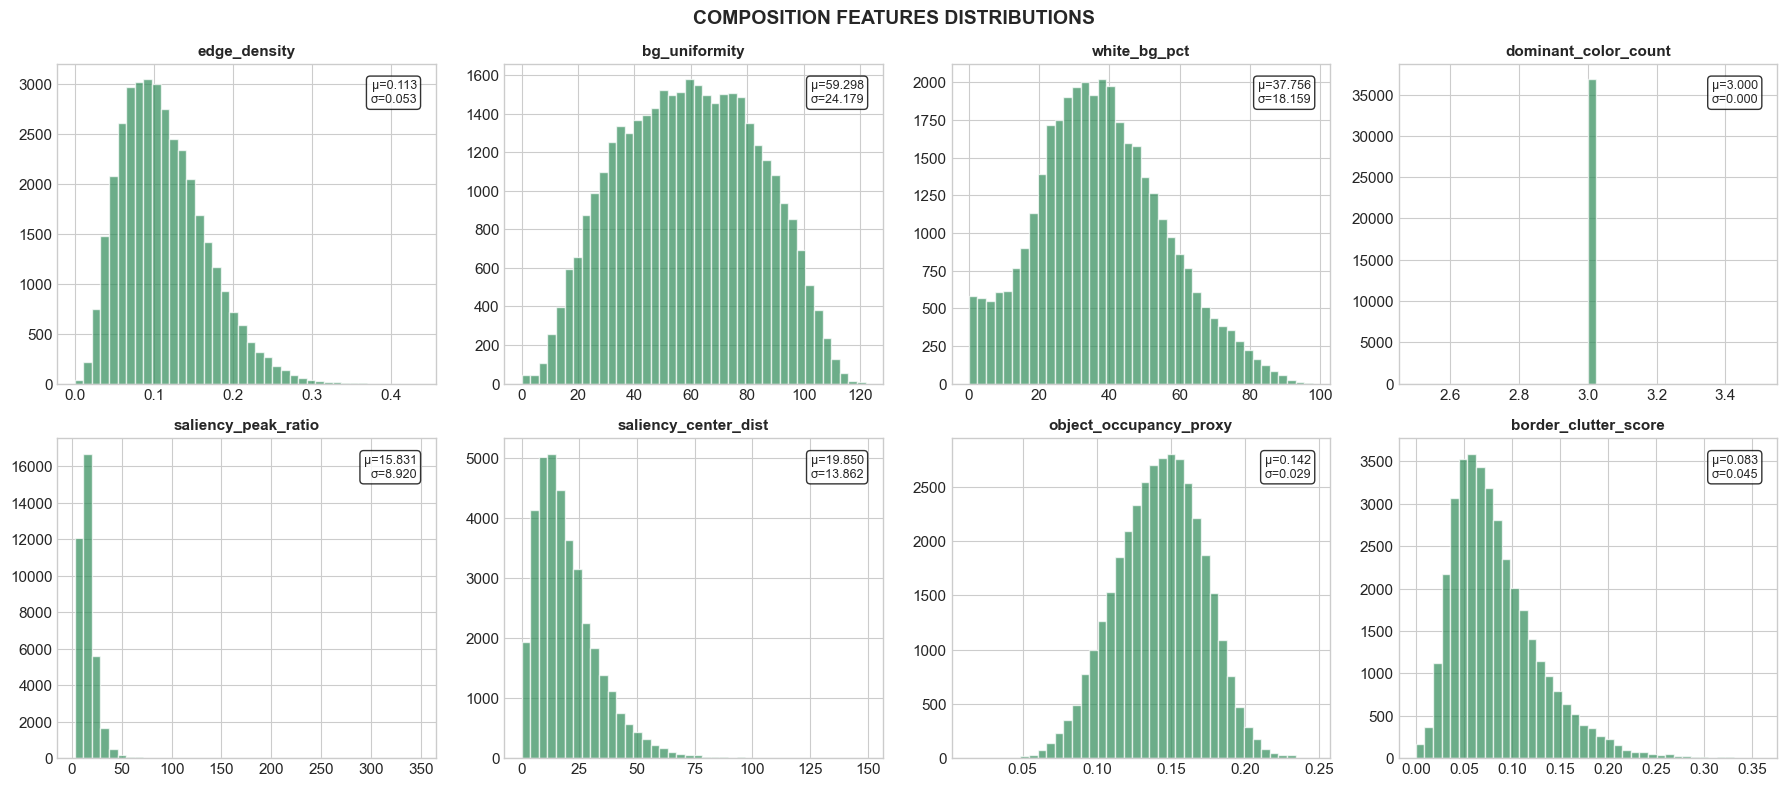

In [9]:
# Composition Features Distribution
composition_cols_mean = get_feature_cols(COMPOSITION_BASE_FEATURES, '_mean')

print("Composition Feature Columns:")
print(composition_cols_mean)

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for idx, col in enumerate(composition_cols_mean[:8]):
    ax = axes[idx]
    data = df_analysis[col].dropna()
    ax.hist(data, bins=40, color='seagreen', alpha=0.7, edgecolor='white')
    ax.set_title(col.replace('_mean', ''), fontsize=11, fontweight='bold')
    
    # Add statistics
    stats_text = f'μ={data.mean():.3f}\nσ={data.std():.3f}'
    ax.text(0.95, 0.95, stats_text, transform=ax.transAxes, fontsize=9,
            verticalalignment='top', horizontalalignment='right',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

for idx in range(len(composition_cols_mean), len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('COMPOSITION FEATURES DISTRIBUTIONS', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

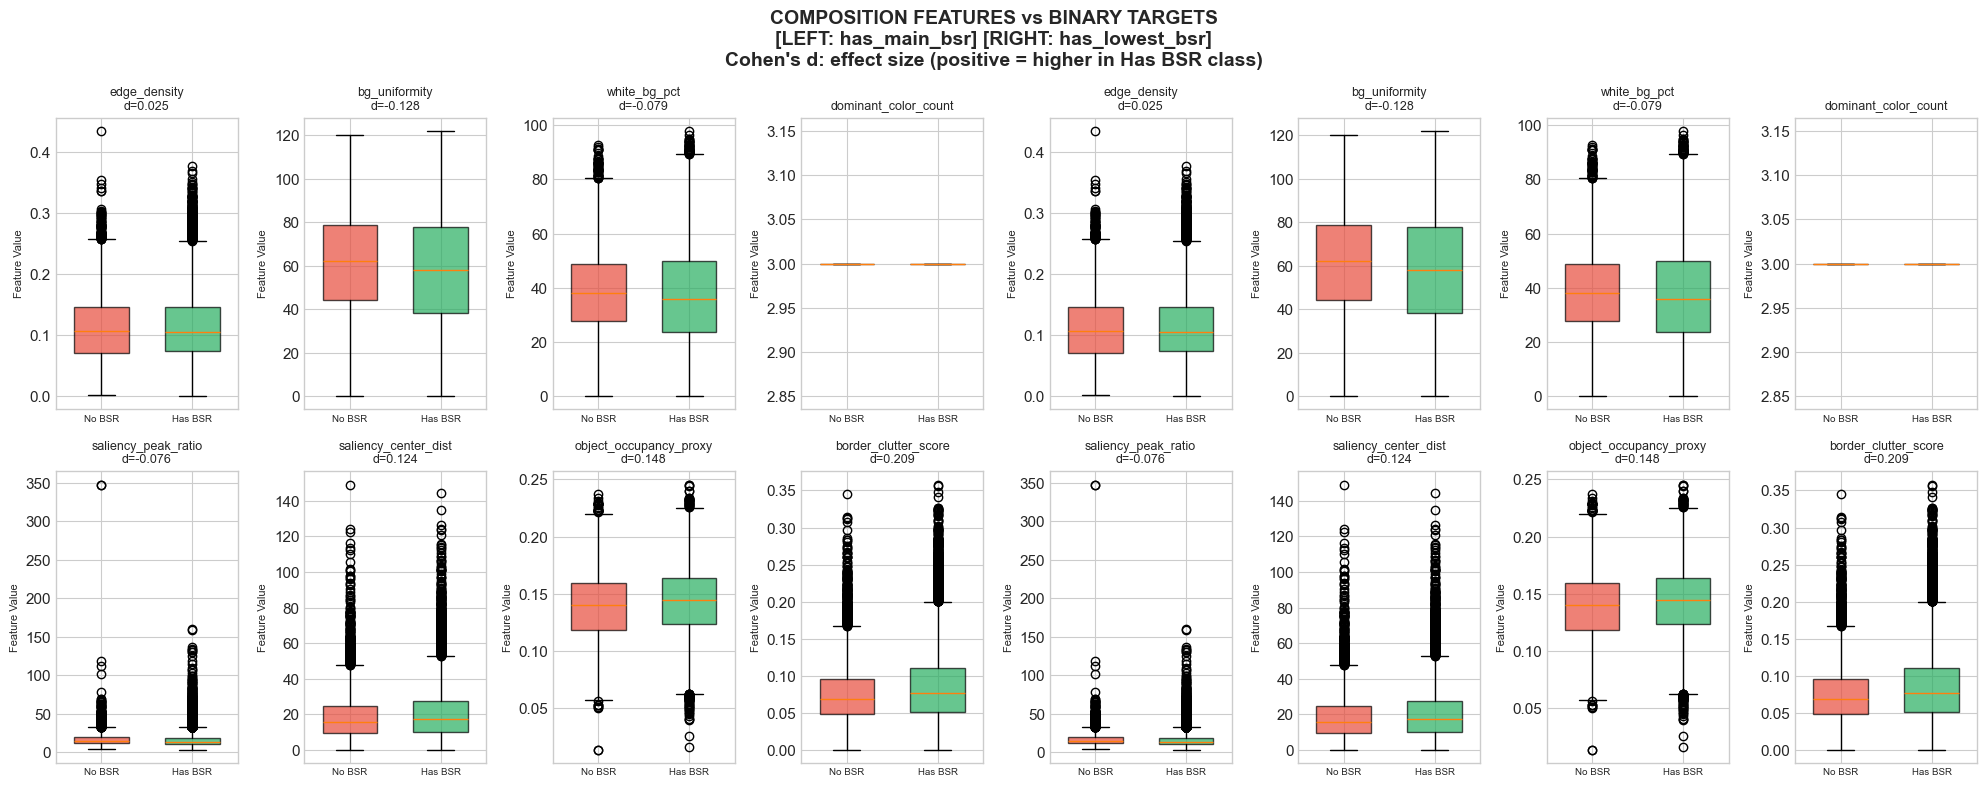

In [10]:
# Composition Features vs Both Targets
plot_feature_vs_targets(composition_cols_mean, 'COMPOSITION FEATURES', n_cols=4)

---
## 5. OCR (TEXT DETECTION) FEATURES
From `image_feature_extraction.ipynb`: Text detection using Tesseract OCR
- **ocr_char_count**: Total characters detected in image
- **ocr_word_count**: Total words detected
- **ocr_num_count**: Numeric tokens found (prices, quantities, etc.)
- **ocr_allcaps_ratio**: Ratio of ALL CAPS words
- **ocr_has_units**: Binary - presence of unit indicators (oz, lb, ml, pack, etc.)
- **ocr_has_claims**: Binary - presence of marketing claims (organic, premium, etc.)
- **text_overlay_area_proxy**: Estimated area covered by text overlays

OCR Feature Columns:
['ocr_char_count_mean', 'ocr_word_count_mean', 'ocr_num_count_mean', 'ocr_allcaps_ratio_mean', 'ocr_has_units_mean', 'ocr_has_claims_mean', 'text_overlay_area_proxy_mean']


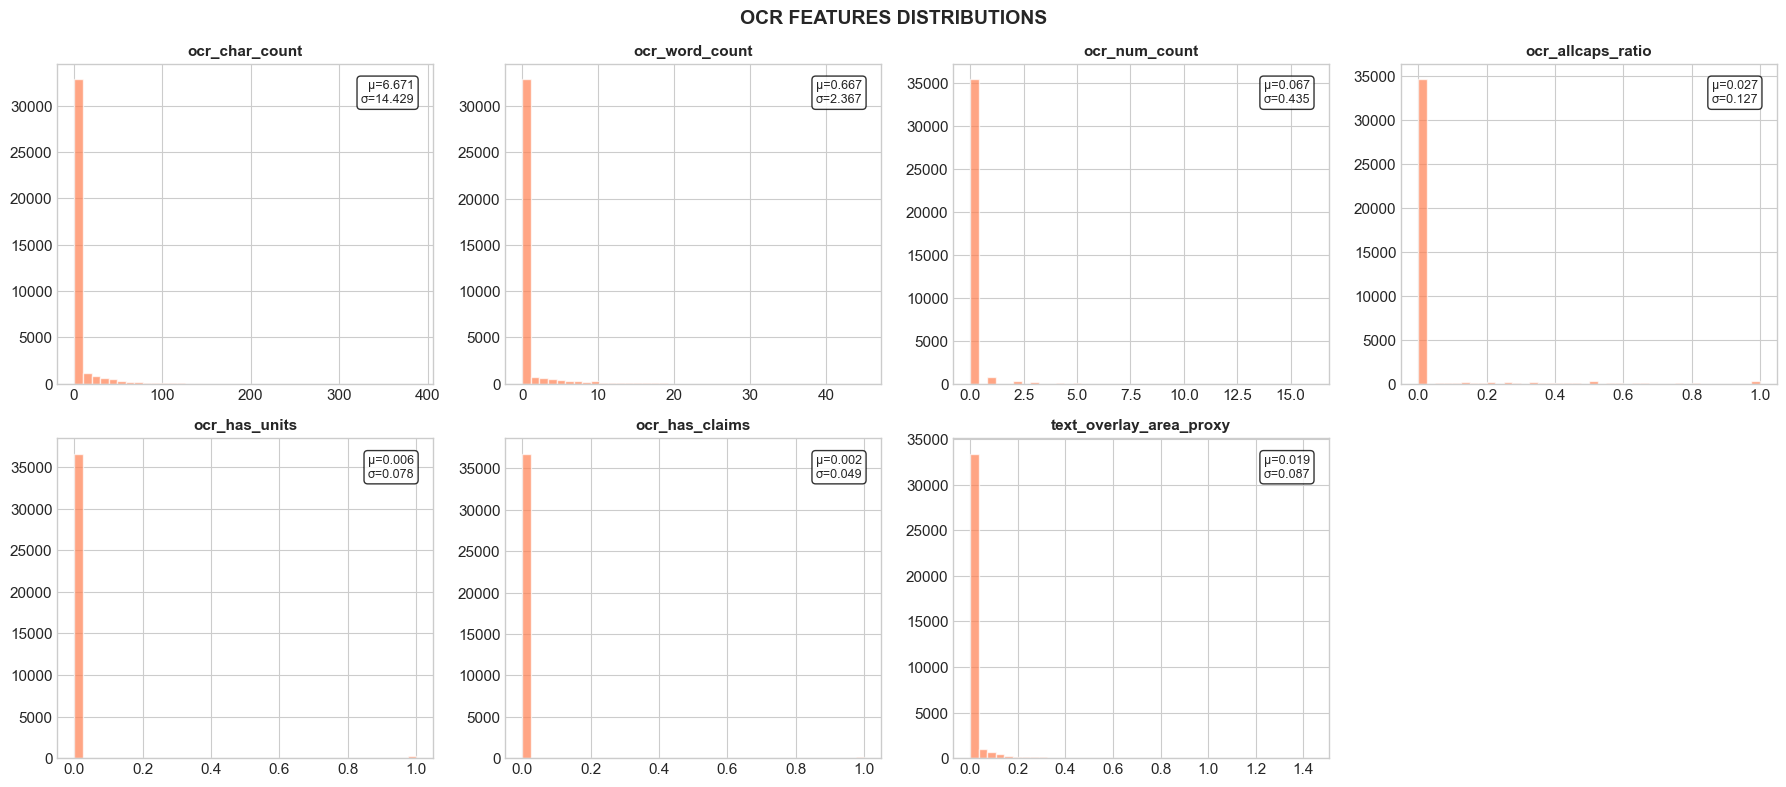

In [11]:
# OCR Features Distribution
ocr_cols_mean = get_feature_cols(OCR_BASE_FEATURES, '_mean')

print("OCR Feature Columns:")
print(ocr_cols_mean)

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for idx, col in enumerate(ocr_cols_mean[:8]):
    ax = axes[idx]
    data = df_analysis[col].dropna()
    ax.hist(data, bins=40, color='coral', alpha=0.7, edgecolor='white')
    ax.set_title(col.replace('_mean', ''), fontsize=11, fontweight='bold')
    
    # Add statistics
    stats_text = f'μ={data.mean():.3f}\nσ={data.std():.3f}'
    ax.text(0.95, 0.95, stats_text, transform=ax.transAxes, fontsize=9,
            verticalalignment='top', horizontalalignment='right',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

for idx in range(len(ocr_cols_mean), len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('OCR FEATURES DISTRIBUTIONS', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

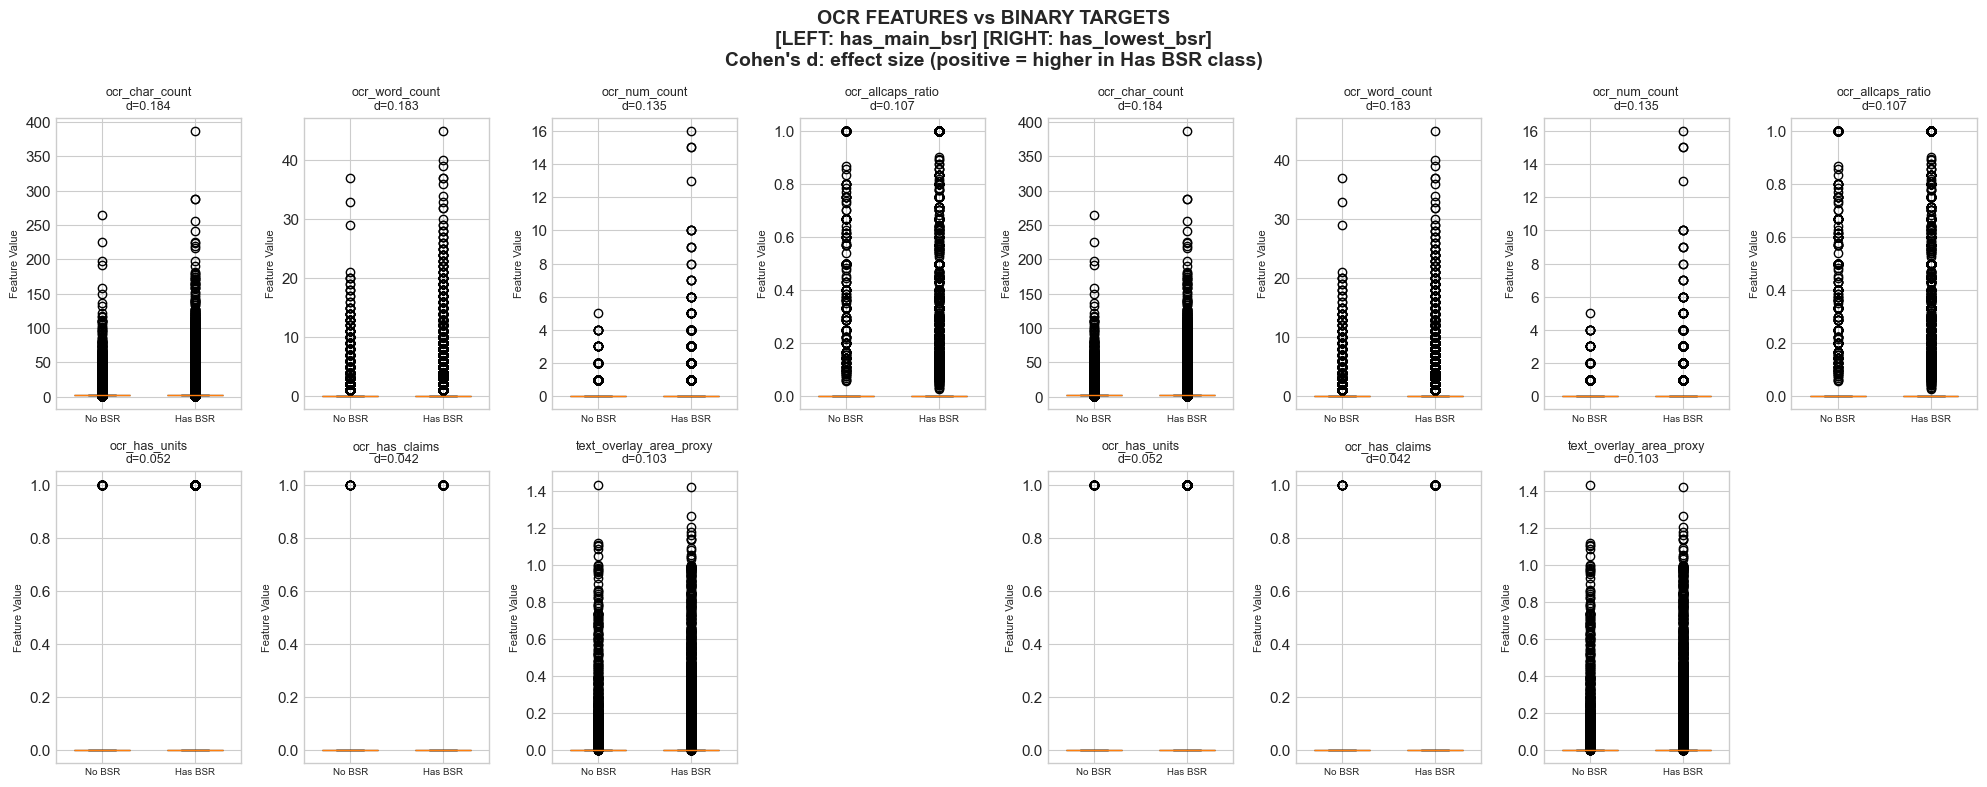

In [12]:
# OCR Features vs Both Targets
plot_feature_vs_targets(ocr_cols_mean, 'OCR FEATURES', n_cols=4)

---
## 6. OBJECT DETECTION FEATURES
From `image_feature_extraction.ipynb`: Object detection using YOLOv8
- **det_num_objects**: Number of detected objects in image
- **det_main_box_area_ratio**: Area ratio of main detected object to image
- **det_main_box_center_dist**: Distance of main object from image center
- **det_has_person**: Binary - person detected (lifestyle shot indicator)
- **det_has_face**: Binary - face detected
- **det_has_hand**: Binary - hand detected (usage demonstration)
- **det_secondary_objects_count**: Number of secondary objects
- **det_conf_mean/max**: Detection confidence scores

Detection Feature Columns:
['det_num_objects_mean', 'det_main_box_area_ratio_mean', 'det_main_box_center_dist_mean', 'det_has_person_mean', 'det_has_face_mean', 'det_has_hand_mean', 'det_secondary_objects_count_mean', 'det_conf_mean_mean', 'det_conf_max_mean']


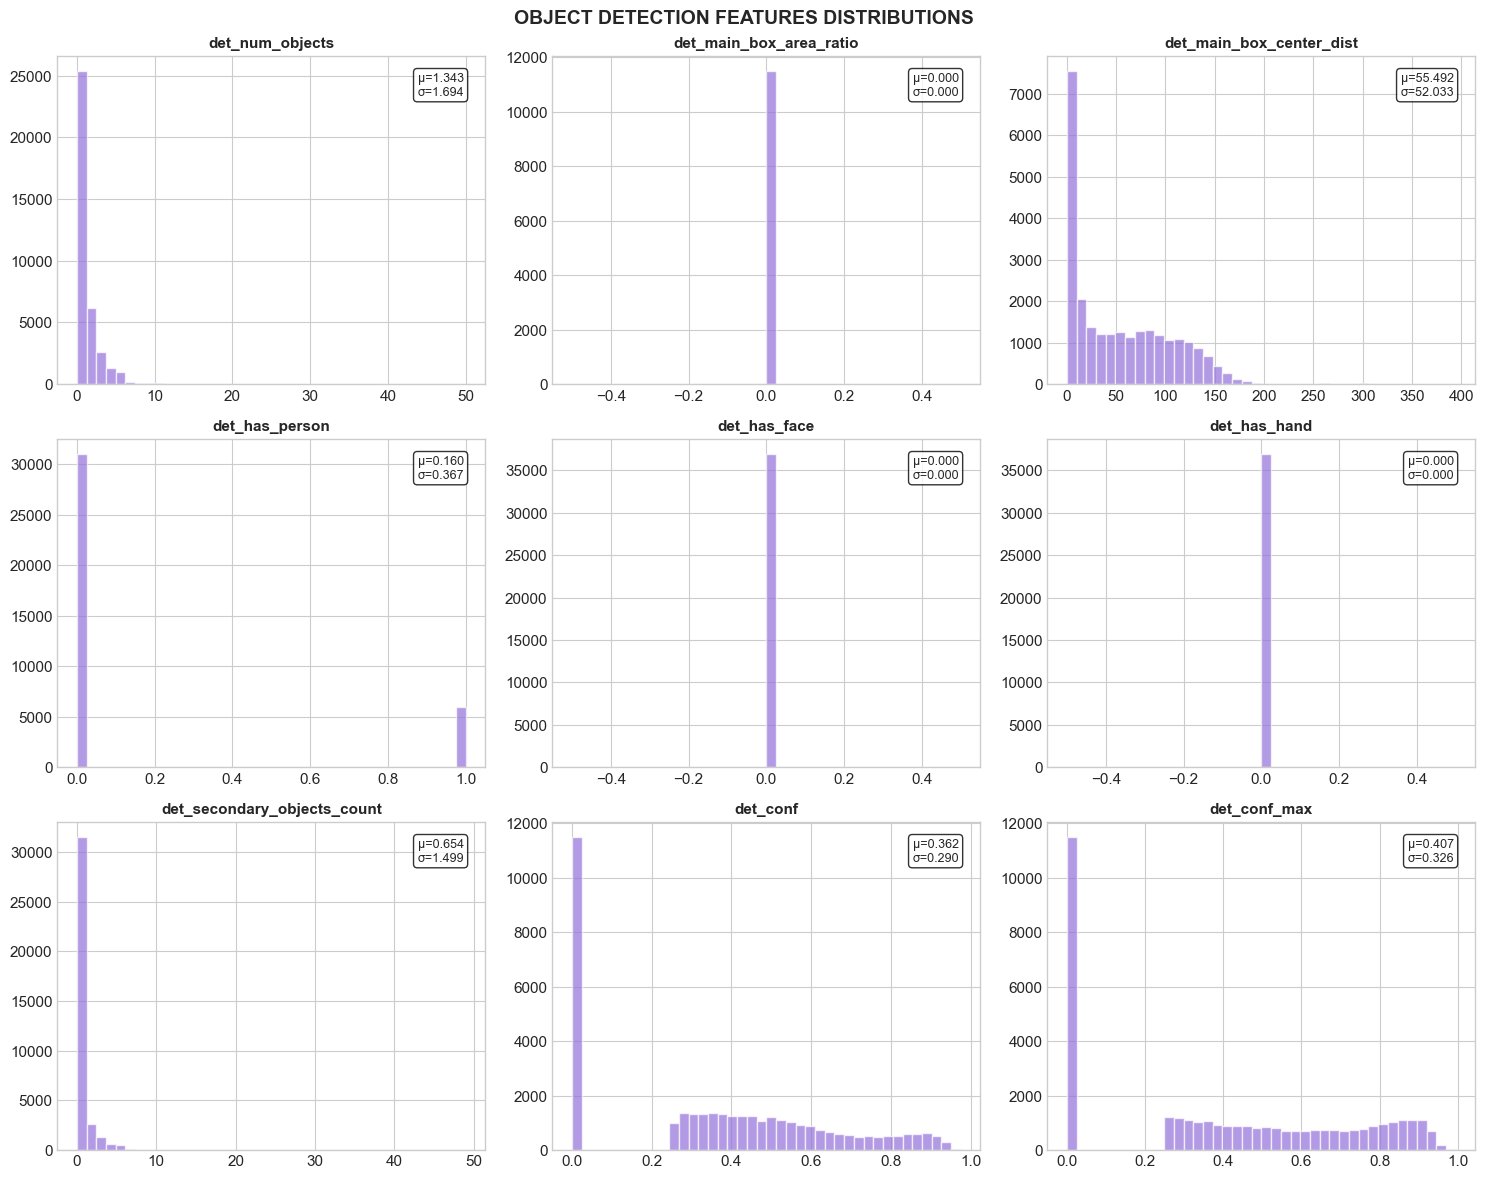

In [13]:
# Detection Features Distribution
detection_cols_mean = get_feature_cols(DETECTION_BASE_FEATURES, '_mean')

print("Detection Feature Columns:")
print(detection_cols_mean)

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for idx, col in enumerate(detection_cols_mean[:9]):
    ax = axes[idx]
    data = df_analysis[col].dropna()
    ax.hist(data, bins=40, color='mediumpurple', alpha=0.7, edgecolor='white')
    ax.set_title(col.replace('_mean', ''), fontsize=11, fontweight='bold')
    
    # Add statistics
    stats_text = f'μ={data.mean():.3f}\nσ={data.std():.3f}'
    ax.text(0.95, 0.95, stats_text, transform=ax.transAxes, fontsize=9,
            verticalalignment='top', horizontalalignment='right',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

for idx in range(len(detection_cols_mean), len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('OBJECT DETECTION FEATURES DISTRIBUTIONS', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

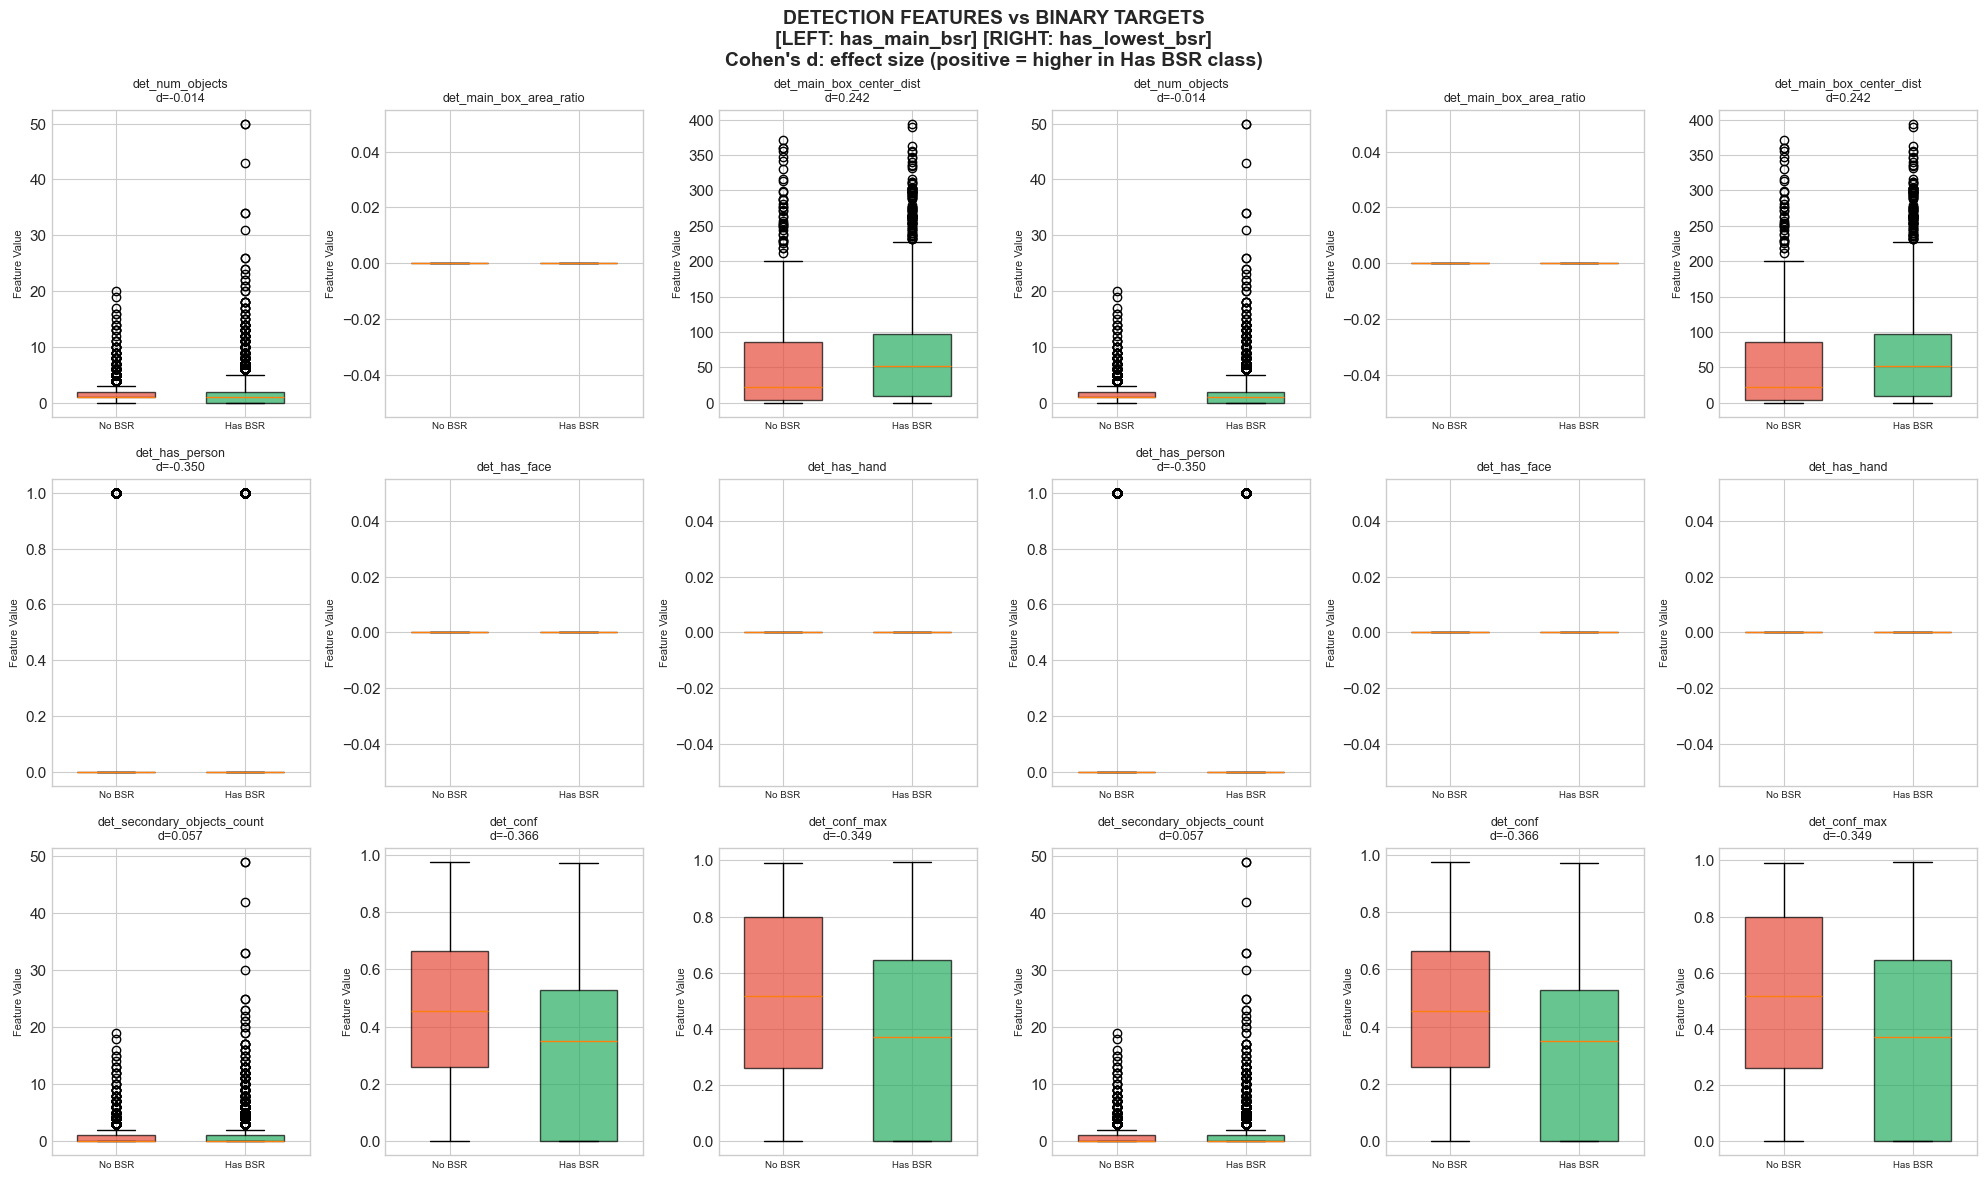

In [14]:
# Detection Features vs Both Targets
plot_feature_vs_targets(detection_cols_mean, 'DETECTION FEATURES', n_cols=3)

---
## 7. PCA EMBEDDING ANALYSIS
From `image_feature_extraction.ipynb`: Deep embeddings compressed via PCA
- **CNN PCA**: EfficientNet-B0 embeddings (1280 dims → 128 PCA components)
- **CLIP PCA**: OpenAI CLIP ViT-B/32 embeddings (512 dims → 128 PCA components)
- **clip_cnn_cos_sim**: Cosine similarity between CNN and CLIP embeddings (alignment metric)

In [15]:
# PCA Embedding Analysis
# Get PCA columns
cnn_pca_cols = [col for col in df_analysis.columns if col.startswith('cnn_pca_')]
clip_pca_cols = [col for col in df_analysis.columns if col.startswith('clip_pca_')]

print(f"CNN PCA components: {len(cnn_pca_cols)}")
print(f"CLIP PCA components: {len(clip_pca_cols)}")

# Check availability
cnn_available = df_analysis[cnn_pca_cols[0]].notna().sum() if cnn_pca_cols else 0
clip_available = df_analysis[clip_pca_cols[0]].notna().sum() if clip_pca_cols else 0
cos_sim_available = df_analysis['clip_cnn_cos_sim'].notna().sum() if 'clip_cnn_cos_sim' in df_analysis.columns else 0

print(f"\nProducts with CNN PCA: {cnn_available:,}")
print(f"Products with CLIP PCA: {clip_available:,}")
print(f"Products with CLIP-CNN cosine similarity: {cos_sim_available:,}")

CNN PCA components: 128
CLIP PCA components: 128

Products with CNN PCA: 36,879
Products with CLIP PCA: 36,879
Products with CLIP-CNN cosine similarity: 36,879


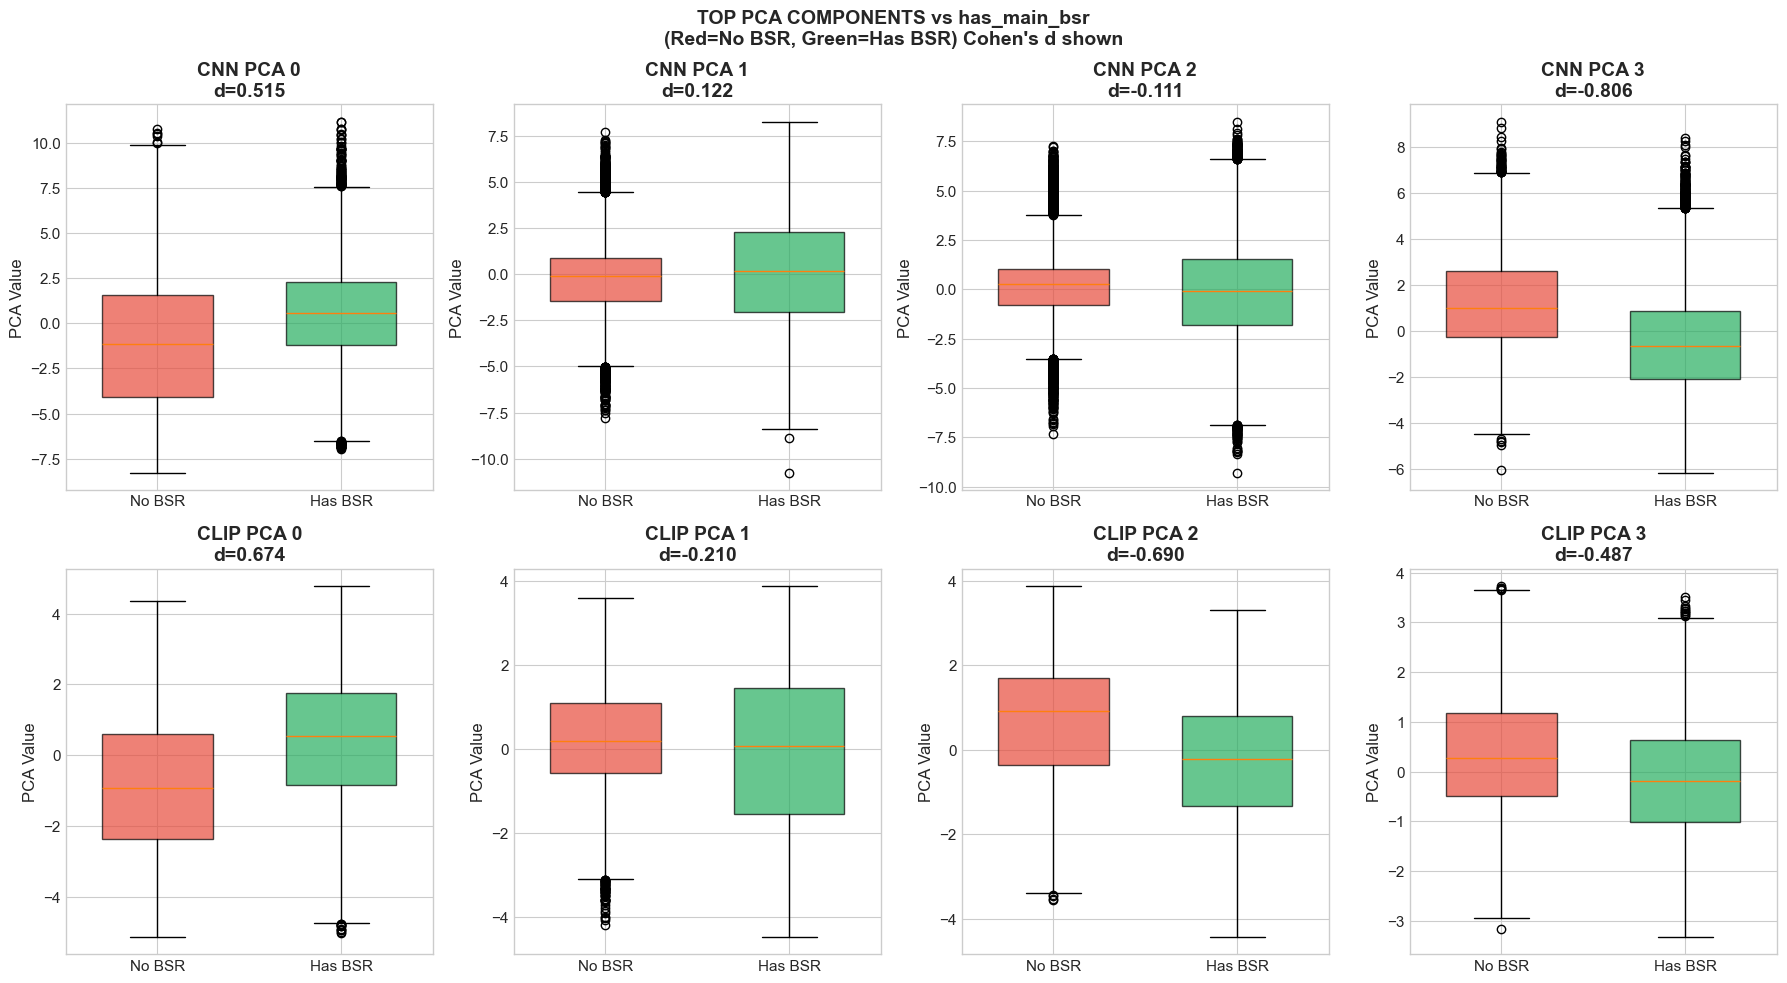

In [16]:
# Visualize first few PCA components and their relationship with binary targets
fig, axes = plt.subplots(2, 4, figsize=(18, 10))

# Top row: CNN PCA vs has_main_bsr (box plots by class)
for i in range(4):
    ax = axes[0, i]
    col = cnn_pca_cols[i] if i < len(cnn_pca_cols) else None
    if col:
        mask = df_analysis[col].notna()
        if mask.sum() > 0:
            data_class0 = df_analysis.loc[mask & (df_analysis['has_main_bsr'] == 0), col]
            data_class1 = df_analysis.loc[mask & (df_analysis['has_main_bsr'] == 1), col]
            
            bp = ax.boxplot([data_class0, data_class1], labels=['No BSR', 'Has BSR'], 
                           patch_artist=True, widths=0.6)
            bp['boxes'][0].set_facecolor(CLASS_0_COLOR)
            bp['boxes'][1].set_facecolor(CLASS_1_COLOR)
            bp['boxes'][0].set_alpha(0.7)
            bp['boxes'][1].set_alpha(0.7)
            
            # Calculate effect size
            if len(data_class0) > 0 and len(data_class1) > 0:
                pooled_std = np.sqrt(((len(data_class0)-1)*data_class0.std()**2 + 
                                     (len(data_class1)-1)*data_class1.std()**2) / 
                                    (len(data_class0) + len(data_class1) - 2))
                if pooled_std > 0:
                    cohens_d = (data_class1.mean() - data_class0.mean()) / pooled_std
                    ax.set_title(f'CNN PCA {i}\nd={cohens_d:.3f}', fontweight='bold')
                else:
                    ax.set_title(f'CNN PCA {i}', fontweight='bold')
            ax.set_ylabel('PCA Value')

# Bottom row: CLIP PCA vs has_main_bsr (box plots by class)
for i in range(4):
    ax = axes[1, i]
    col = clip_pca_cols[i] if i < len(clip_pca_cols) else None
    if col:
        mask = df_analysis[col].notna()
        if mask.sum() > 0:
            data_class0 = df_analysis.loc[mask & (df_analysis['has_main_bsr'] == 0), col]
            data_class1 = df_analysis.loc[mask & (df_analysis['has_main_bsr'] == 1), col]
            
            bp = ax.boxplot([data_class0, data_class1], labels=['No BSR', 'Has BSR'], 
                           patch_artist=True, widths=0.6)
            bp['boxes'][0].set_facecolor(CLASS_0_COLOR)
            bp['boxes'][1].set_facecolor(CLASS_1_COLOR)
            bp['boxes'][0].set_alpha(0.7)
            bp['boxes'][1].set_alpha(0.7)
            
            # Calculate effect size
            if len(data_class0) > 0 and len(data_class1) > 0:
                pooled_std = np.sqrt(((len(data_class0)-1)*data_class0.std()**2 + 
                                     (len(data_class1)-1)*data_class1.std()**2) / 
                                    (len(data_class0) + len(data_class1) - 2))
                if pooled_std > 0:
                    cohens_d = (data_class1.mean() - data_class0.mean()) / pooled_std
                    ax.set_title(f'CLIP PCA {i}\nd={cohens_d:.3f}', fontweight='bold')
                else:
                    ax.set_title(f'CLIP PCA {i}', fontweight='bold')
            ax.set_ylabel('PCA Value')

plt.suptitle('TOP PCA COMPONENTS vs has_main_bsr\n(Red=No BSR, Green=Has BSR) Cohen\'s d shown', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

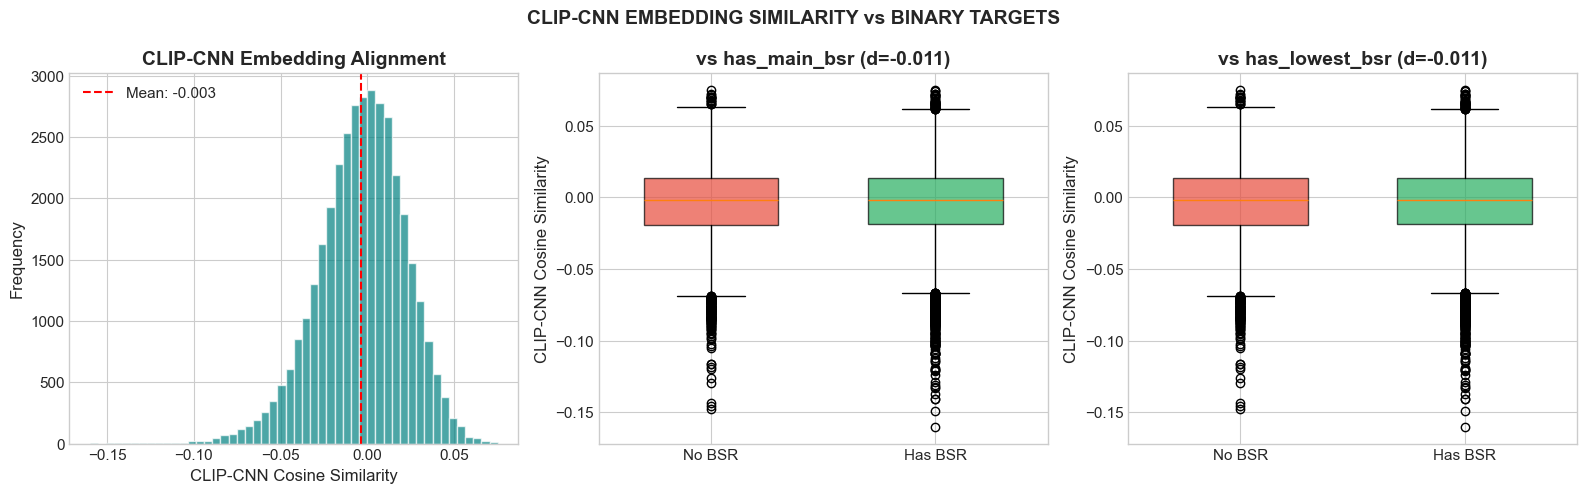

In [17]:
# CLIP-CNN Cosine Similarity Analysis for Binary Classification
if 'clip_cnn_cos_sim' in df_analysis.columns:
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    
    # Distribution
    ax1 = axes[0]
    cos_sim_data = df_analysis['clip_cnn_cos_sim'].dropna()
    ax1.hist(cos_sim_data, bins=50, color='teal', alpha=0.7, edgecolor='white')
    ax1.axvline(cos_sim_data.mean(), color='red', linestyle='--', 
                label=f'Mean: {cos_sim_data.mean():.3f}')
    ax1.set_xlabel('CLIP-CNN Cosine Similarity')
    ax1.set_ylabel('Frequency')
    ax1.set_title('CLIP-CNN Embedding Alignment', fontweight='bold')
    ax1.legend()
    
    # vs has_main_bsr (box plot by class)
    ax2 = axes[1]
    mask = df_analysis['clip_cnn_cos_sim'].notna()
    if mask.sum() > 0:
        data_class0 = df_analysis.loc[mask & (df_analysis['has_main_bsr'] == 0), 'clip_cnn_cos_sim']
        data_class1 = df_analysis.loc[mask & (df_analysis['has_main_bsr'] == 1), 'clip_cnn_cos_sim']
        
        bp = ax2.boxplot([data_class0, data_class1], labels=['No BSR', 'Has BSR'], 
                        patch_artist=True, widths=0.6)
        bp['boxes'][0].set_facecolor(CLASS_0_COLOR)
        bp['boxes'][1].set_facecolor(CLASS_1_COLOR)
        bp['boxes'][0].set_alpha(0.7)
        bp['boxes'][1].set_alpha(0.7)
        
        # Calculate effect size
        if len(data_class0) > 0 and len(data_class1) > 0:
            pooled_std = np.sqrt(((len(data_class0)-1)*data_class0.std()**2 + 
                                 (len(data_class1)-1)*data_class1.std()**2) / 
                                (len(data_class0) + len(data_class1) - 2))
            if pooled_std > 0:
                cohens_d = (data_class1.mean() - data_class0.mean()) / pooled_std
                ax2.set_title(f'vs has_main_bsr (d={cohens_d:.3f})', fontweight='bold')
    ax2.set_ylabel('CLIP-CNN Cosine Similarity')
    
    # vs has_lowest_bsr (box plot by class)
    ax3 = axes[2]
    if mask.sum() > 0:
        data_class0 = df_analysis.loc[mask & (df_analysis['has_lowest_bsr'] == 0), 'clip_cnn_cos_sim']
        data_class1 = df_analysis.loc[mask & (df_analysis['has_lowest_bsr'] == 1), 'clip_cnn_cos_sim']
        
        bp = ax3.boxplot([data_class0, data_class1], labels=['No BSR', 'Has BSR'], 
                        patch_artist=True, widths=0.6)
        bp['boxes'][0].set_facecolor(CLASS_0_COLOR)
        bp['boxes'][1].set_facecolor(CLASS_1_COLOR)
        bp['boxes'][0].set_alpha(0.7)
        bp['boxes'][1].set_alpha(0.7)
        
        # Calculate effect size
        if len(data_class0) > 0 and len(data_class1) > 0:
            pooled_std = np.sqrt(((len(data_class0)-1)*data_class0.std()**2 + 
                                 (len(data_class1)-1)*data_class1.std()**2) / 
                                (len(data_class0) + len(data_class1) - 2))
            if pooled_std > 0:
                cohens_d = (data_class1.mean() - data_class0.mean()) / pooled_std
                ax3.set_title(f'vs has_lowest_bsr (d={cohens_d:.3f})', fontweight='bold')
    ax3.set_ylabel('CLIP-CNN Cosine Similarity')
    
    plt.suptitle('CLIP-CNN EMBEDDING SIMILARITY vs BINARY TARGETS', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print("clip_cnn_cos_sim column not found in dataset")

---
## 8. CORRELATION ANALYSIS
Comprehensive correlation analysis between image features and both BSR targets:
- Pearson correlation coefficients
- Spearman rank correlation (for non-linear relationships)
- Comparison between Main BSR and Lowest BSR correlations

In [18]:
# Point-Biserial Correlation Analysis for Binary Classification
def compute_pointbiserial_correlations(df, feature_cols, target_col):
    """Compute point-biserial correlations between continuous features and binary target"""
    correlations = {}
    for col in feature_cols:
        mask = df[col].notna()
        if mask.sum() > 10:
            # Point-biserial correlation is mathematically equivalent to Pearson r 
            # when one variable is binary (0/1)
            corr, pval = stats.pointbiserialr(df.loc[mask, target_col], df.loc[mask, col])
            correlations[col] = {'correlation': corr, 'p_value': pval, 'n': mask.sum()}
    return pd.DataFrame(correlations).T

def compute_effect_sizes(df, feature_cols, target_col):
    """Compute Cohen's d effect sizes between feature values for each class"""
    effect_sizes = {}
    for col in feature_cols:
        mask = df[col].notna()
        if mask.sum() > 10:
            class0 = df.loc[mask & (df[target_col] == 0), col]
            class1 = df.loc[mask & (df[target_col] == 1), col]
            
            if len(class0) > 1 and len(class1) > 1:
                pooled_std = np.sqrt(((len(class0)-1)*class0.std()**2 + 
                                     (len(class1)-1)*class1.std()**2) / 
                                    (len(class0) + len(class1) - 2))
                if pooled_std > 0:
                    cohens_d = (class1.mean() - class0.mean()) / pooled_std
                    effect_sizes[col] = {
                        'cohens_d': cohens_d,
                        'mean_class0': class0.mean(),
                        'mean_class1': class1.mean(),
                        'n_class0': len(class0),
                        'n_class1': len(class1)
                    }
    return pd.DataFrame(effect_sizes).T

# Collect all image feature columns (mean aggregation)
all_feature_cols = (
    get_feature_cols(QUALITY_BASE_FEATURES, '_mean') +
    get_feature_cols(COMPOSITION_BASE_FEATURES, '_mean') +
    get_feature_cols(OCR_BASE_FEATURES, '_mean') +
    get_feature_cols(DETECTION_BASE_FEATURES, '_mean') +
    ['num_images', 'clip_cnn_cos_sim']
)
all_feature_cols = [c for c in all_feature_cols if c in df_analysis.columns]

# Add first 10 PCA components
all_feature_cols += cnn_pca_cols[:10] + clip_pca_cols[:10]

# Compute point-biserial correlations for both binary targets
print("Computing Point-Biserial correlations for has_main_bsr...")
corr_main_bsr = compute_pointbiserial_correlations(df_analysis, all_feature_cols, 'has_main_bsr')

print("Computing Point-Biserial correlations for has_lowest_bsr...")
corr_lowest_bsr = compute_pointbiserial_correlations(df_analysis, all_feature_cols, 'has_lowest_bsr')

# Compute effect sizes
print("Computing Cohen's d effect sizes...")
effect_main_bsr = compute_effect_sizes(df_analysis, all_feature_cols, 'has_main_bsr')
effect_lowest_bsr = compute_effect_sizes(df_analysis, all_feature_cols, 'has_lowest_bsr')

print(f"Features analyzed: {len(all_feature_cols)}")

Computing Point-Biserial correlations for has_main_bsr...
Computing Point-Biserial correlations for has_lowest_bsr...
Computing Cohen's d effect sizes...
Features analyzed: 61


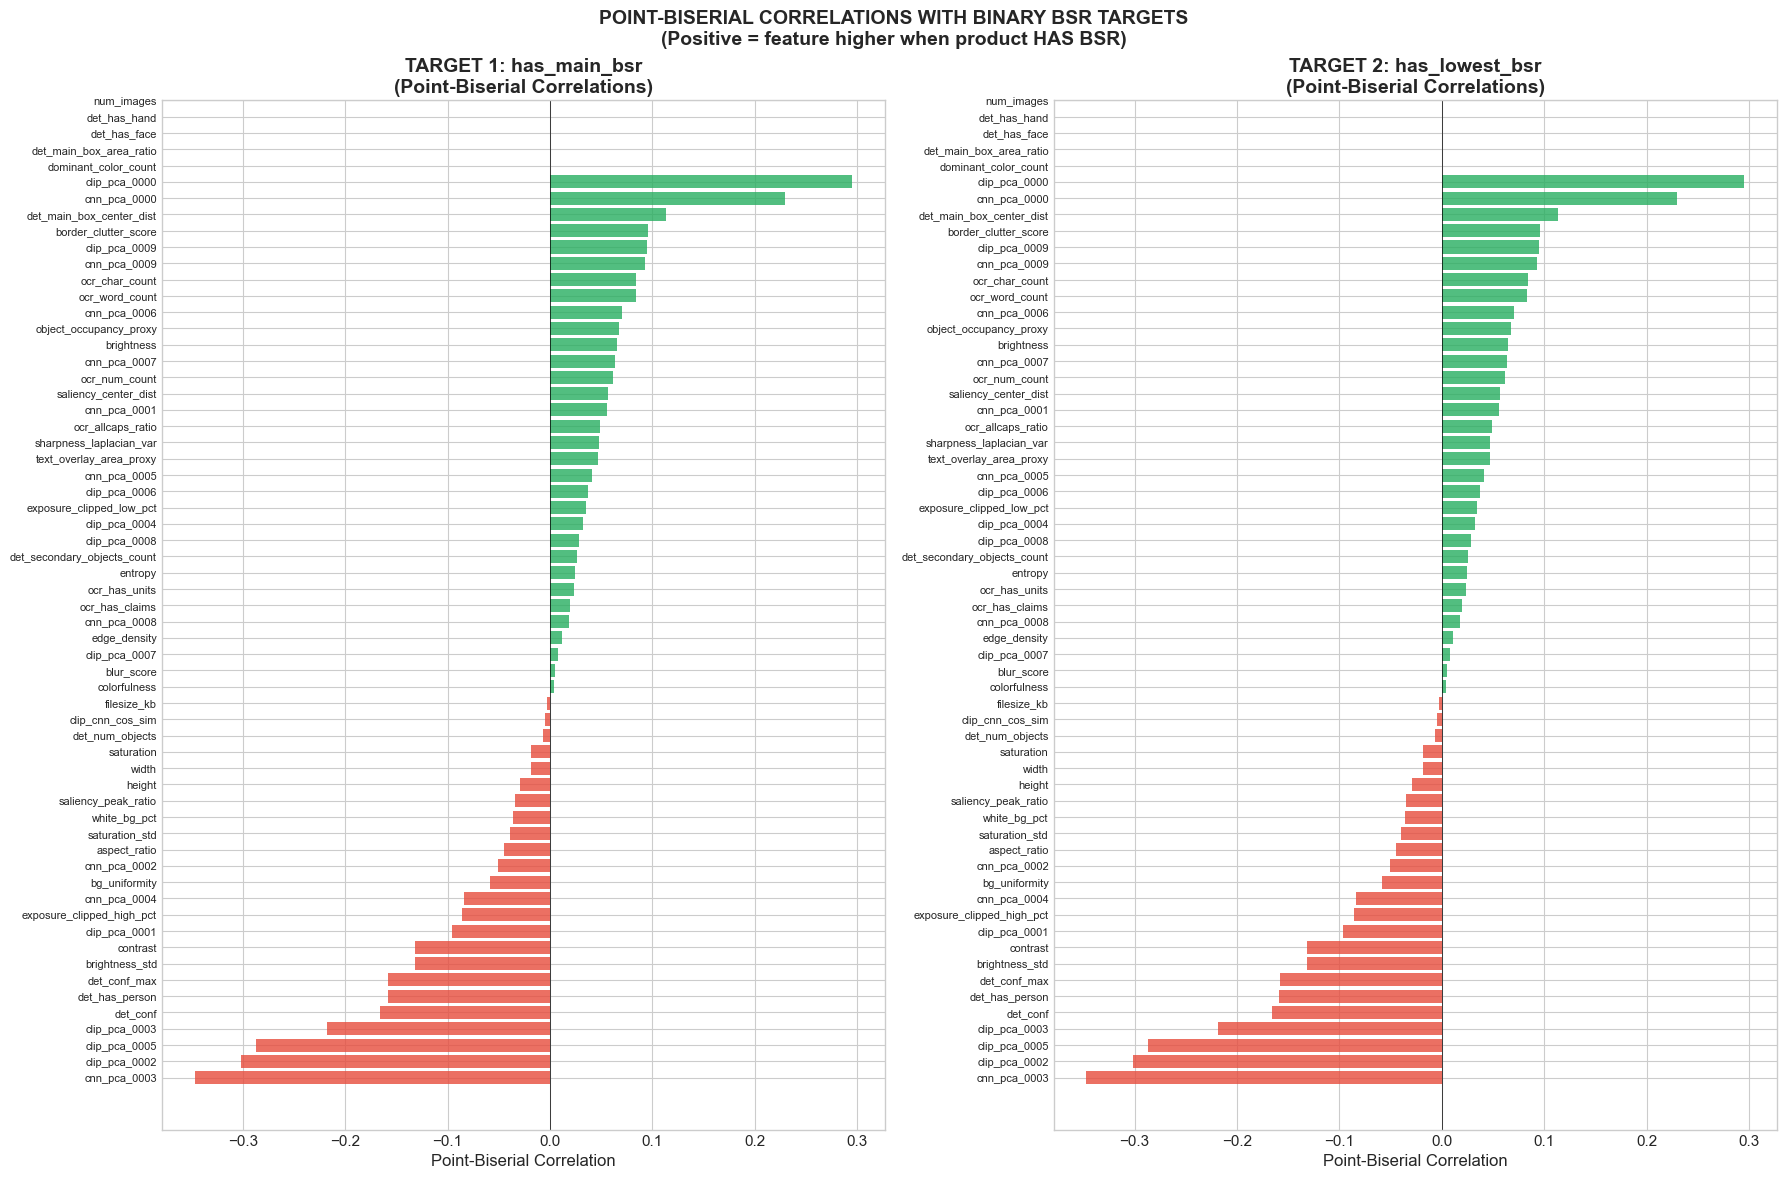

In [19]:
# Point-Biserial Correlation Plot for Binary Classification
fig, axes = plt.subplots(1, 2, figsize=(18, 12))

# has_main_bsr Correlations (sorted)
ax1 = axes[0]
main_corr_sorted = corr_main_bsr['correlation'].sort_values()
colors_main = [CLASS_1_COLOR if c >= 0 else CLASS_0_COLOR for c in main_corr_sorted.values]
y_pos = range(len(main_corr_sorted))
ax1.barh(y_pos, main_corr_sorted.values, color=colors_main, alpha=0.8)
ax1.set_yticks(y_pos)
ax1.set_yticklabels([s.replace('_mean', '') for s in main_corr_sorted.index], fontsize=8)
ax1.axvline(0, color='black', linestyle='-', linewidth=0.5)
ax1.set_xlabel('Point-Biserial Correlation')
ax1.set_title('TARGET 1: has_main_bsr\n(Point-Biserial Correlations)', fontweight='bold')

# has_lowest_bsr Correlations (sorted)
ax2 = axes[1]
lowest_corr_sorted = corr_lowest_bsr['correlation'].sort_values()
colors_lowest = [CLASS_1_COLOR if c >= 0 else CLASS_0_COLOR for c in lowest_corr_sorted.values]
y_pos = range(len(lowest_corr_sorted))
ax2.barh(y_pos, lowest_corr_sorted.values, color=colors_lowest, alpha=0.8)
ax2.set_yticks(y_pos)
ax2.set_yticklabels([s.replace('_mean', '') for s in lowest_corr_sorted.index], fontsize=8)
ax2.axvline(0, color='black', linestyle='-', linewidth=0.5)
ax2.set_xlabel('Point-Biserial Correlation')
ax2.set_title('TARGET 2: has_lowest_bsr\n(Point-Biserial Correlations)', fontweight='bold')

plt.suptitle('POINT-BISERIAL CORRELATIONS WITH BINARY BSR TARGETS\n(Positive = feature higher when product HAS BSR)', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [22]:
# Side-by-side Correlation and Effect Size Comparison
# Create comparison DataFrame
comparison_df = pd.DataFrame({
    'has_main_bsr (r_pb)': corr_main_bsr['correlation'],
    'has_lowest_bsr (r_pb)': corr_lowest_bsr['correlation'],
    'has_main_bsr (d)': effect_main_bsr['cohens_d'] if 'cohens_d' in effect_main_bsr.columns else None,
    'has_lowest_bsr (d)': effect_lowest_bsr['cohens_d'] if 'cohens_d' in effect_lowest_bsr.columns else None
}).dropna()

# Sort by average absolute correlation
comparison_df['avg_abs_corr'] = (comparison_df['has_main_bsr (r_pb)'].abs() + 
                                  comparison_df['has_lowest_bsr (r_pb)'].abs()) / 2
comparison_df = comparison_df.sort_values('avg_abs_corr', ascending=False)

# Display top correlations
print("="*80)
print("TOP 20 FEATURES BY CORRELATION WITH BINARY TARGETS")
print("="*80)
print("\nr_pb = Point-Biserial Correlation")
print("d = Cohen's d effect size")
print("\n(Positive values = feature is HIGHER when product HAS a BSR)")
print("(Negative values = feature is LOWER when product HAS a BSR)\n")
display_df = comparison_df[['has_main_bsr (r_pb)', 'has_lowest_bsr (r_pb)', 
                            'has_main_bsr (d)', 'has_lowest_bsr (d)']].head(20)
print(display_df.round(4).to_string())

TOP 20 FEATURES BY CORRELATION WITH BINARY TARGETS

r_pb = Point-Biserial Correlation
d = Cohen's d effect size

(Positive values = feature is HIGHER when product HAS a BSR)
(Negative values = feature is LOWER when product HAS a BSR)

                                has_main_bsr (r_pb)  has_lowest_bsr (r_pb)  has_main_bsr (d)  has_lowest_bsr (d)
cnn_pca_0003                                -0.3471                -0.3471           -0.8065             -0.8065
clip_pca_0002                               -0.3018                -0.3018           -0.6899             -0.6899
clip_pca_0000                                0.2953                 0.2953            0.6737              0.6737
clip_pca_0005                               -0.2870                -0.2870           -0.6529             -0.6529
cnn_pca_0000                                 0.2300                 0.2300            0.5151              0.5151
clip_pca_0003                               -0.2181                -0.2181           -0

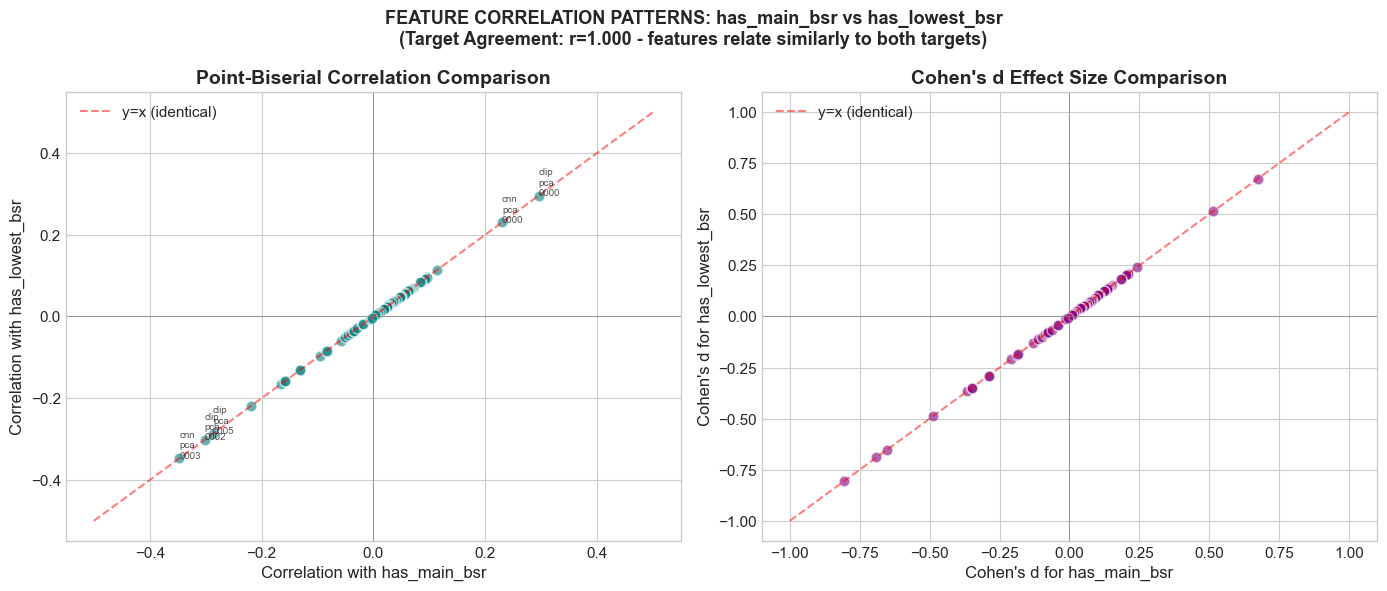

In [23]:
# Correlation scatter: has_main_bsr vs has_lowest_bsr
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Point-Biserial Correlation
ax1 = axes[0]
ax1.scatter(comparison_df['has_main_bsr (r_pb)'], 
            comparison_df['has_lowest_bsr (r_pb)'],
            alpha=0.6, s=60, c='teal', edgecolor='white')
ax1.plot([-0.5, 0.5], [-0.5, 0.5], 'r--', alpha=0.5, label='y=x (identical)')
ax1.axhline(0, color='gray', linestyle='-', linewidth=0.5)
ax1.axvline(0, color='gray', linestyle='-', linewidth=0.5)
ax1.set_xlabel('Correlation with has_main_bsr', fontsize=12)
ax1.set_ylabel('Correlation with has_lowest_bsr', fontsize=12)
ax1.set_title('Point-Biserial Correlation Comparison', fontweight='bold')
ax1.legend()

# Add annotations for top features
for idx in comparison_df.head(5).index:
    ax1.annotate(idx.replace('_mean', '').replace('_', '\n'), 
                (comparison_df.loc[idx, 'has_main_bsr (r_pb)'],
                 comparison_df.loc[idx, 'has_lowest_bsr (r_pb)']),
                fontsize=7, alpha=0.8)

# Cohen's d Effect Size
ax2 = axes[1]
ax2.scatter(comparison_df['has_main_bsr (d)'], 
            comparison_df['has_lowest_bsr (d)'],
            alpha=0.6, s=60, c='purple', edgecolor='white')
ax2.plot([-1, 1], [-1, 1], 'r--', alpha=0.5, label='y=x (identical)')
ax2.axhline(0, color='gray', linestyle='-', linewidth=0.5)
ax2.axvline(0, color='gray', linestyle='-', linewidth=0.5)
ax2.set_xlabel("Cohen's d for has_main_bsr", fontsize=12)
ax2.set_ylabel("Cohen's d for has_lowest_bsr", fontsize=12)
ax2.set_title("Cohen's d Effect Size Comparison", fontweight='bold')
ax2.legend()

# Compute correlation between the two target correlations
corr_agreement = np.corrcoef(comparison_df['has_main_bsr (r_pb)'], 
                             comparison_df['has_lowest_bsr (r_pb)'])[0, 1]

plt.suptitle(f'FEATURE CORRELATION PATTERNS: has_main_bsr vs has_lowest_bsr\n' +
             f'(Target Agreement: r={corr_agreement:.3f} - features relate similarly to both targets)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 9. MUTUAL INFORMATION ANALYSIS
Mutual Information captures non-linear dependencies that Pearson/Spearman correlations may miss.
MI quantifies how much information a feature provides about the target variable.

Higher MI = stronger predictive relationship (regardless of linearity)

In [24]:
# Mutual Information Calculation for Binary Classification
def compute_mutual_information_classif(df, feature_cols, target_col, n_neighbors=5):
    """Compute mutual information between continuous features and binary target"""
    # Get full dataset (target is now binary - no missing values)
    df_subset = df.copy()
    
    # Binary target (no log transform needed)
    y = df_subset[target_col].values
    
    # Build feature matrix (impute NaNs with median for MI calculation)
    X_list = []
    valid_cols = []
    for col in feature_cols:
        if col in df_subset.columns:
            x = df_subset[col].values.copy()
            # Impute NaNs with median
            nan_mask = np.isnan(x)
            if nan_mask.sum() < len(x) * 0.5:  # Only include if <50% missing
                x[nan_mask] = np.nanmedian(x)
                X_list.append(x)
                valid_cols.append(col)
    
    if not X_list:
        return pd.Series()
    
    X = np.column_stack(X_list)
    
    # Compute mutual information for classification
    mi_scores = mutual_info_classif(X, y, n_neighbors=n_neighbors, random_state=42)
    
    return pd.Series(mi_scores, index=valid_cols)

# Compute MI for both binary targets
print("Computing Mutual Information for has_main_bsr (classification)...")
mi_main = compute_mutual_information_classif(df_analysis, all_feature_cols, 'has_main_bsr')

print("Computing Mutual Information for has_lowest_bsr (classification)...")
mi_lowest = compute_mutual_information_classif(df_analysis, all_feature_cols, 'has_lowest_bsr')

print(f"\nFeatures with MI scores: {len(mi_main)}")

Computing Mutual Information for has_main_bsr (classification)...
Computing Mutual Information for has_lowest_bsr (classification)...

Features with MI scores: 60


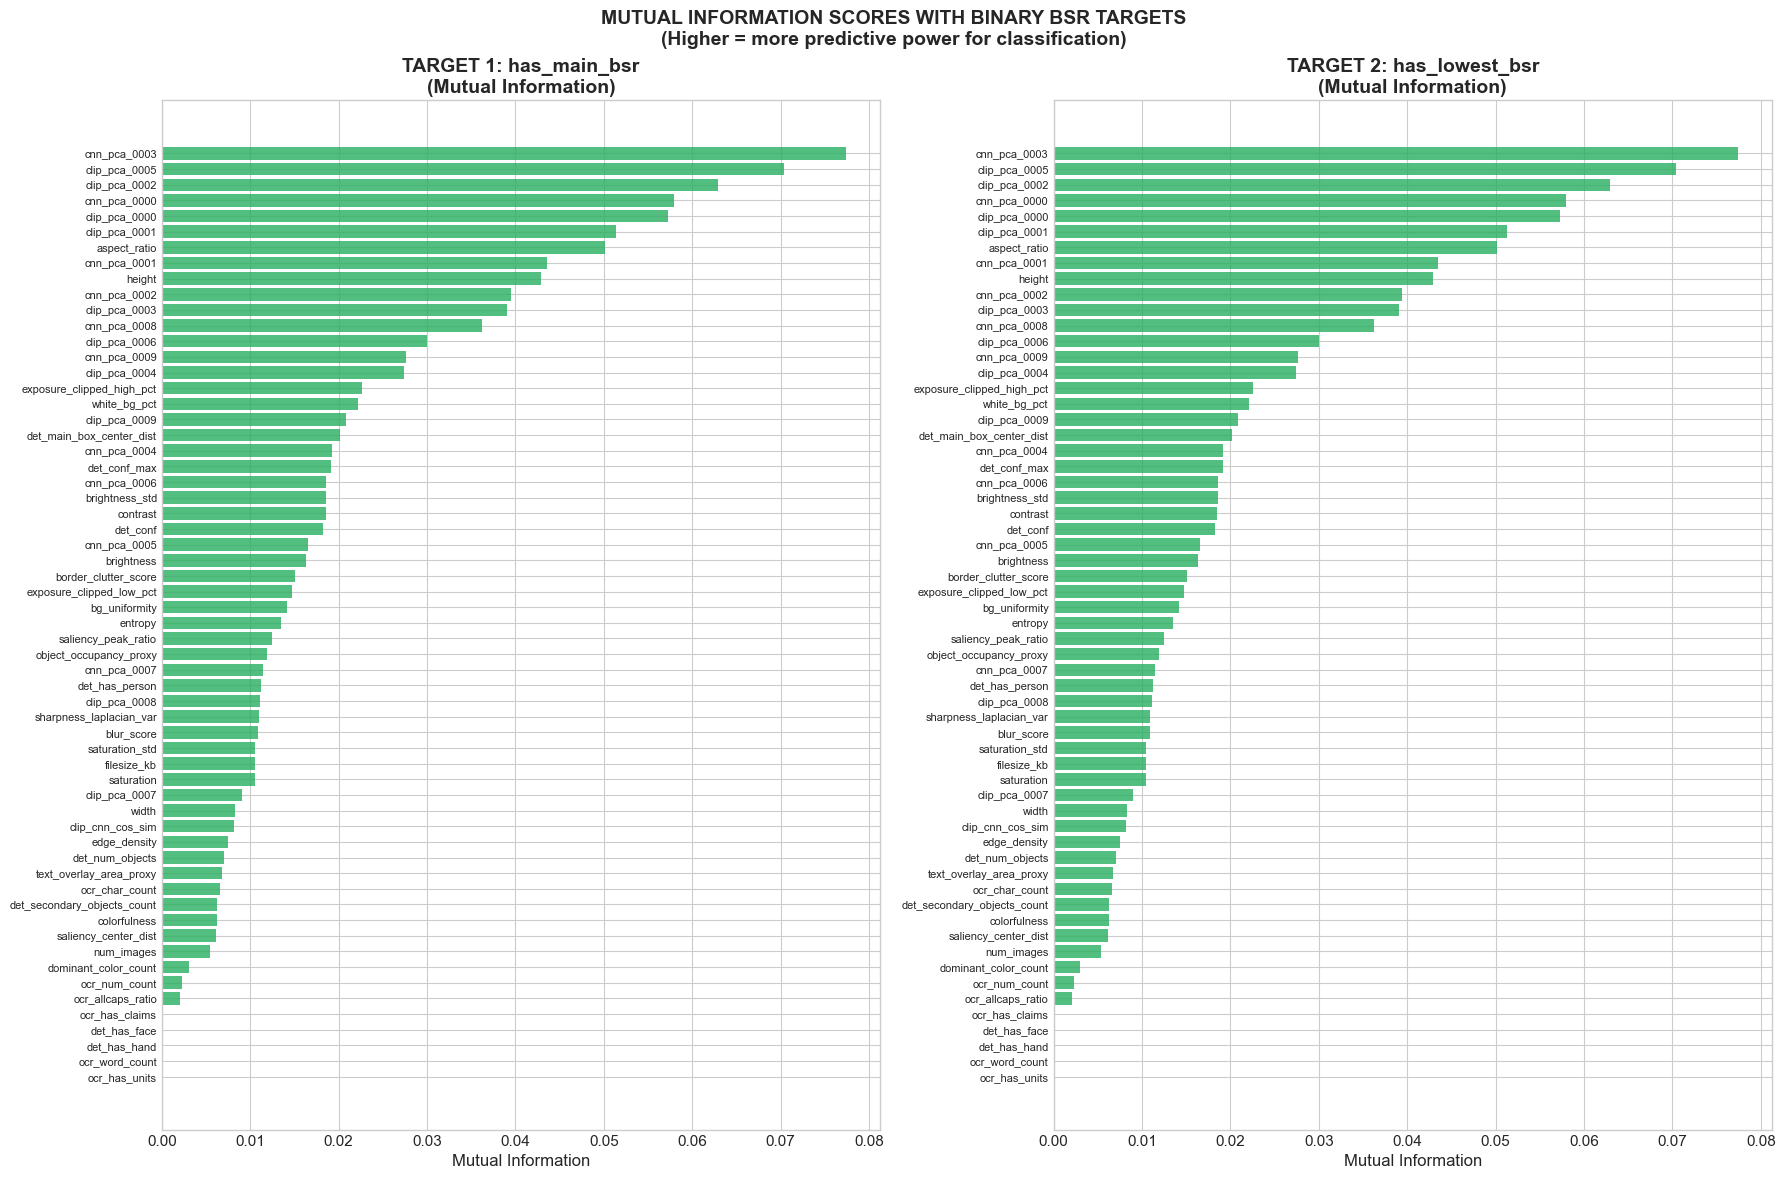

In [25]:
# Mutual Information Comparison Plot for Binary Classification
fig, axes = plt.subplots(1, 2, figsize=(18, 12))

# has_main_bsr MI (sorted)
ax1 = axes[0]
mi_main_sorted = mi_main.sort_values(ascending=True)
y_pos = range(len(mi_main_sorted))
ax1.barh(y_pos, mi_main_sorted.values, color=CLASS_1_COLOR, alpha=0.8)
ax1.set_yticks(y_pos)
ax1.set_yticklabels([s.replace('_mean', '') for s in mi_main_sorted.index], fontsize=8)
ax1.set_xlabel('Mutual Information')
ax1.set_title('TARGET 1: has_main_bsr\n(Mutual Information)', fontweight='bold')

# has_lowest_bsr MI (sorted)
ax2 = axes[1]
mi_lowest_sorted = mi_lowest.sort_values(ascending=True)
y_pos = range(len(mi_lowest_sorted))
ax2.barh(y_pos, mi_lowest_sorted.values, color=CLASS_1_COLOR, alpha=0.8)
ax2.set_yticks(y_pos)
ax2.set_yticklabels([s.replace('_mean', '') for s in mi_lowest_sorted.index], fontsize=8)
ax2.set_xlabel('Mutual Information')
ax2.set_title('TARGET 2: has_lowest_bsr\n(Mutual Information)', fontweight='bold')

plt.suptitle('MUTUAL INFORMATION SCORES WITH BINARY BSR TARGETS\n(Higher = more predictive power for classification)', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

TOP 20 FEATURES BY MUTUAL INFORMATION (CLASSIFICATION)

(Higher MI = more predictive information for classifying BSR presence)

                                MI_has_main_bsr  MI_has_lowest_bsr  avg_MI
cnn_pca_0003                             0.0774             0.0774  0.0774
clip_pca_0005                            0.0704             0.0704  0.0704
clip_pca_0002                            0.0629             0.0629  0.0629
cnn_pca_0000                             0.0580             0.0580  0.0580
clip_pca_0000                            0.0573             0.0573  0.0573
clip_pca_0001                            0.0513             0.0513  0.0513
aspect_ratio_mean                        0.0502             0.0502  0.0502
cnn_pca_0001                             0.0435             0.0435  0.0435
height_mean                              0.0429             0.0429  0.0429
cnn_pca_0002                             0.0394             0.0394  0.0394
clip_pca_0003                            0.0390

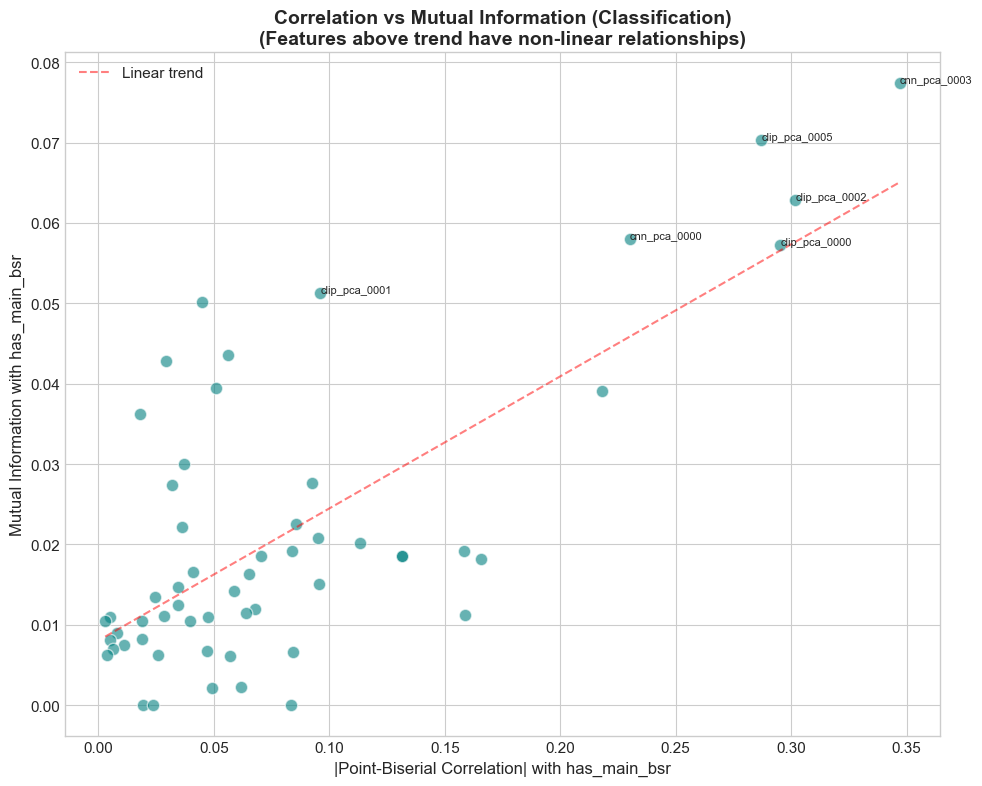

In [26]:
# Top Mutual Information Features for Binary Classification
mi_comparison = pd.DataFrame({
    'MI_has_main_bsr': mi_main,
    'MI_has_lowest_bsr': mi_lowest
}).dropna()

mi_comparison['avg_MI'] = (mi_comparison['MI_has_main_bsr'] + mi_comparison['MI_has_lowest_bsr']) / 2
mi_comparison = mi_comparison.sort_values('avg_MI', ascending=False)

print("="*70)
print("TOP 20 FEATURES BY MUTUAL INFORMATION (CLASSIFICATION)")
print("="*70)
print("\n(Higher MI = more predictive information for classifying BSR presence)\n")
print(mi_comparison.head(20).round(4).to_string())

# MI vs Point-Biserial Correlation scatter
fig, ax = plt.subplots(figsize=(10, 8))

common_idx = mi_comparison.index.intersection(comparison_df.index)
x = comparison_df.loc[common_idx, 'has_main_bsr (r_pb)'].abs()
y = mi_comparison.loc[common_idx, 'MI_has_main_bsr']

ax.scatter(x, y, alpha=0.6, s=80, c='teal', edgecolor='white')
ax.set_xlabel('|Point-Biserial Correlation| with has_main_bsr', fontsize=12)
ax.set_ylabel('Mutual Information with has_main_bsr', fontsize=12)
ax.set_title('Correlation vs Mutual Information (Classification)\n(Features above trend have non-linear relationships)', 
             fontweight='bold')

# Add trend line
z = np.polyfit(x, y, 1)
p = np.poly1d(z)
ax.plot(sorted(x), p(sorted(x)), 'r--', alpha=0.5, label='Linear trend')
ax.legend()

# Annotate outliers (high MI, low correlation)
for idx in common_idx:
    if mi_comparison.loc[idx, 'MI_has_main_bsr'] > y.quantile(0.9):
        ax.annotate(idx.replace('_mean', ''), (x[idx], y[idx]), fontsize=8)

plt.tight_layout()
plt.show()

---
## 10. FEATURE CORRELATION HEATMAP
Visual overview of inter-feature correlations within each feature group

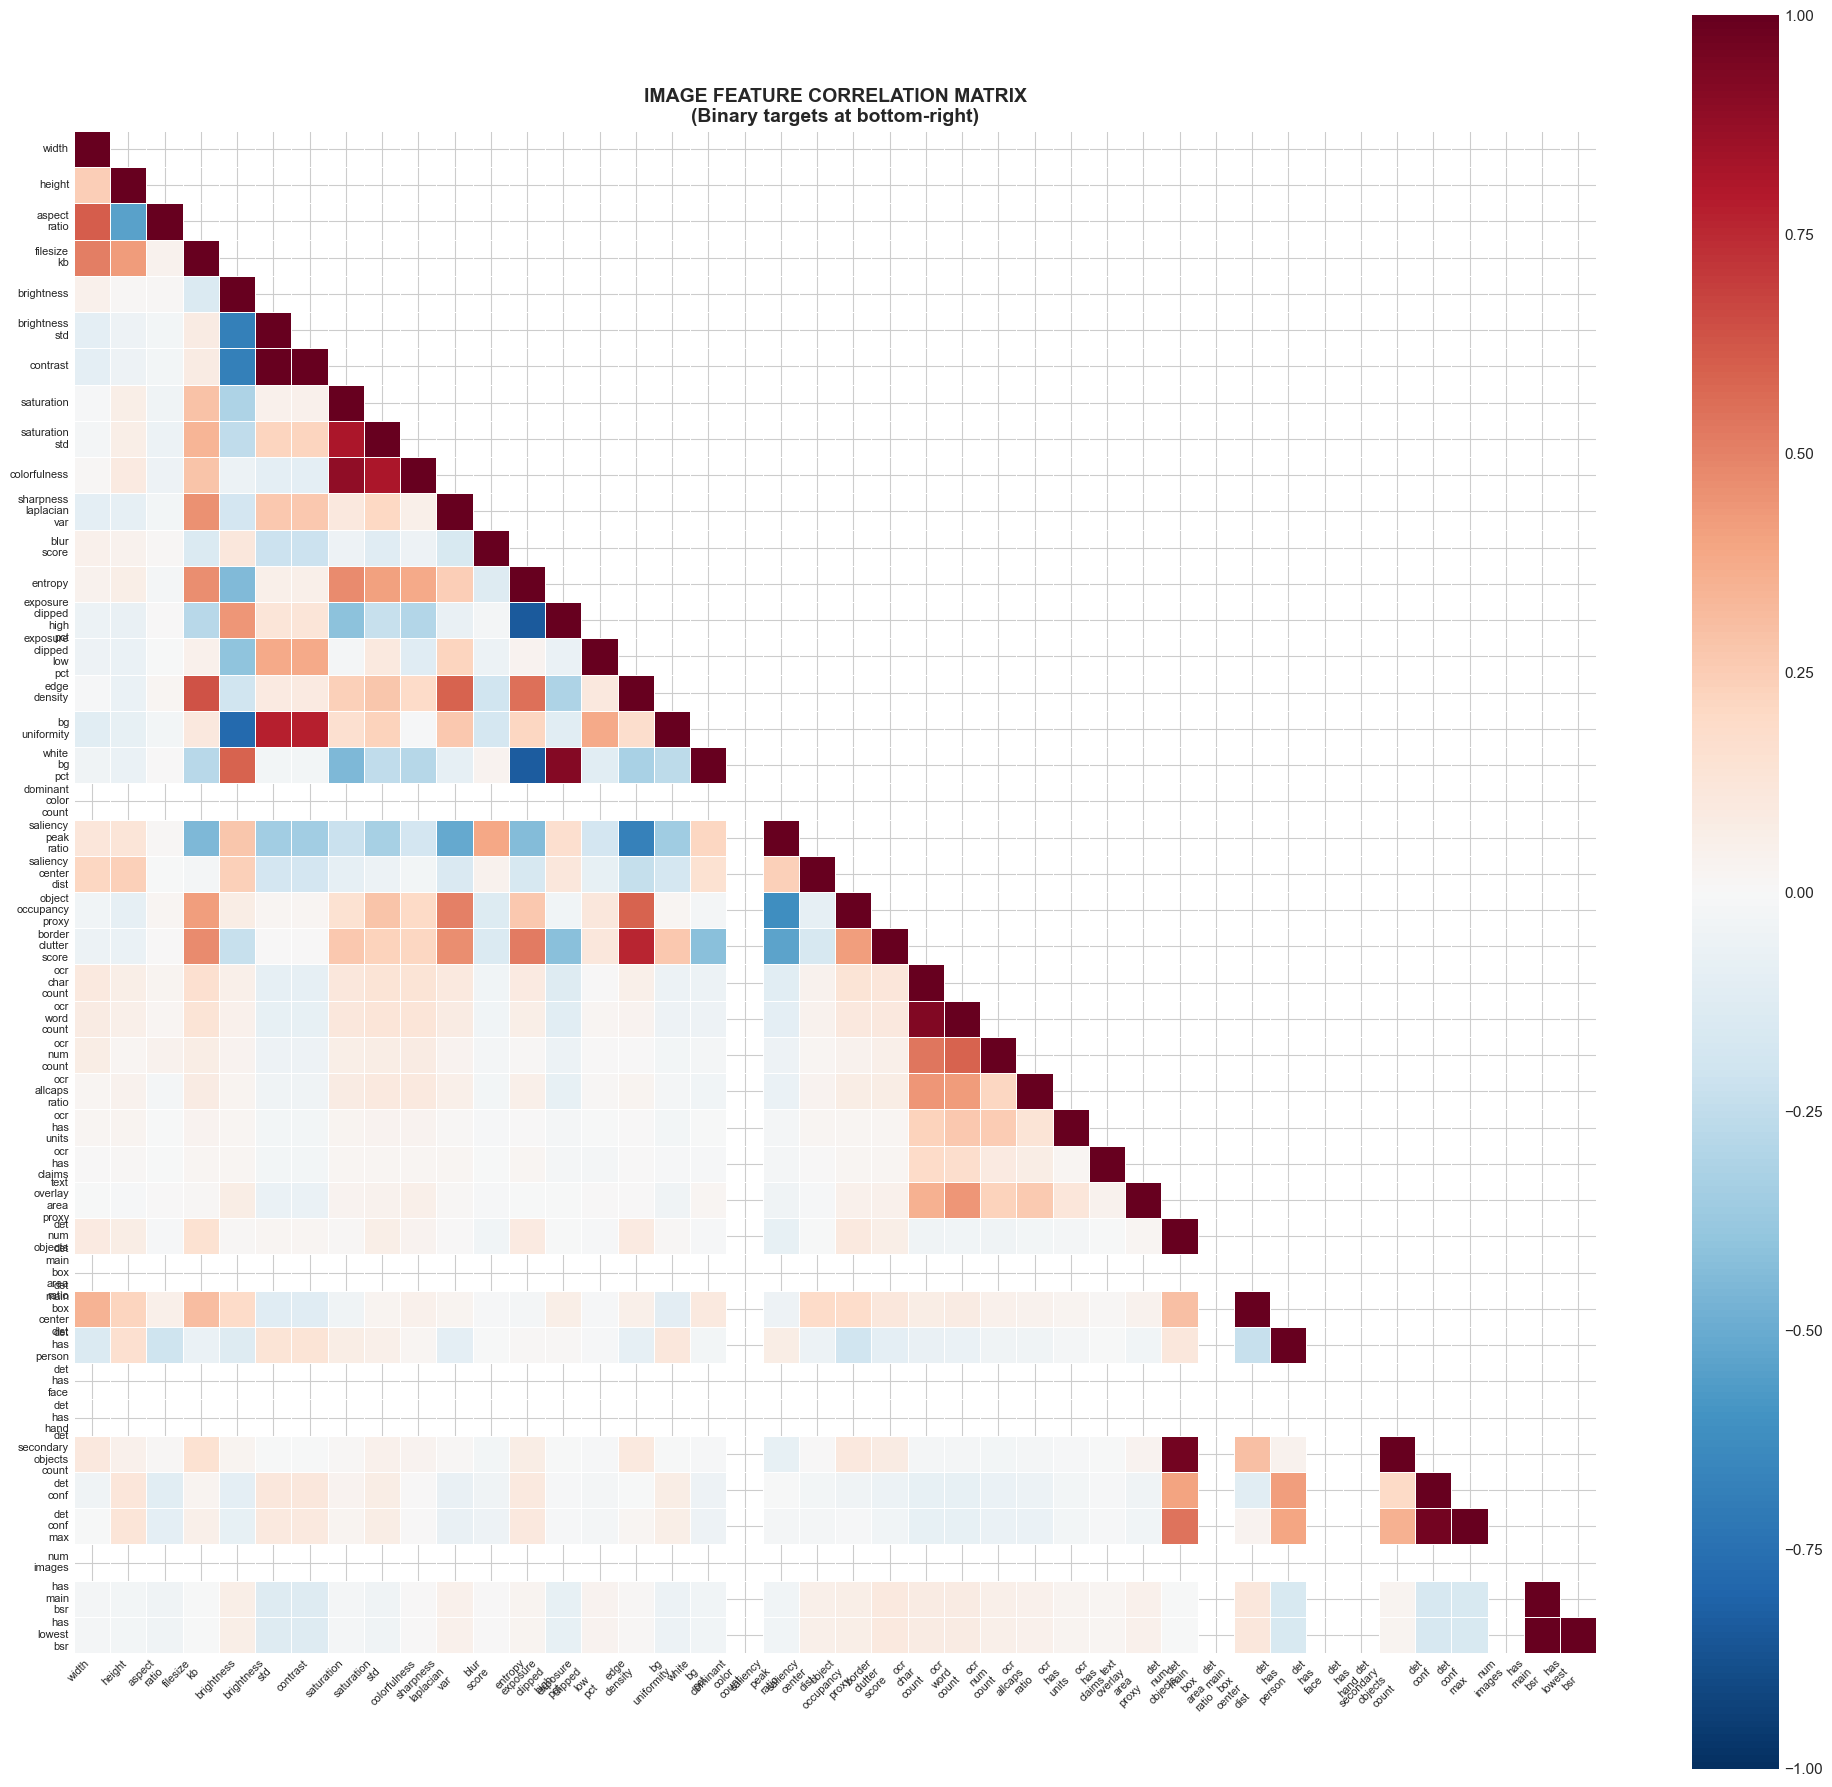

In [27]:
# Feature Correlation Heatmap (non-PCA features only)
non_pca_features = (
    get_feature_cols(QUALITY_BASE_FEATURES, '_mean') +
    get_feature_cols(COMPOSITION_BASE_FEATURES, '_mean') +
    get_feature_cols(OCR_BASE_FEATURES, '_mean') +
    get_feature_cols(DETECTION_BASE_FEATURES, '_mean') +
    ['num_images']
)
non_pca_features = [c for c in non_pca_features if c in df_analysis.columns]

# Add binary targets for reference
feature_for_heatmap = non_pca_features + ['has_main_bsr', 'has_lowest_bsr']

# Compute correlation matrix
corr_matrix = df_analysis[feature_for_heatmap].corr()

# Clean up labels
clean_labels = [s.replace('_mean', '').replace('_', '\n') for s in corr_matrix.columns]

fig, ax = plt.subplots(figsize=(20, 18))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, mask=mask, annot=False, cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, ax=ax,
            xticklabels=clean_labels, yticklabels=clean_labels,
            vmin=-1, vmax=1)
ax.set_title('IMAGE FEATURE CORRELATION MATRIX\n(Binary targets at bottom-right)', 
             fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

---
## 12. COMPREHENSIVE FEATURE RANKING
Combined ranking using multiple metrics: Pearson correlation, Spearman correlation, and Mutual Information

In [28]:
# Comprehensive Feature Ranking for Binary Classification
# Combine all metrics

# Get common features across all metrics
common_features = list(set(corr_main_bsr.index) & 
                       set(corr_lowest_bsr.index) & 
                       set(mi_main.index) & 
                       set(mi_lowest.index) &
                       set(effect_main_bsr.index) &
                       set(effect_lowest_bsr.index))

feature_ranking = pd.DataFrame(index=common_features)

# Point-Biserial correlations (absolute)
feature_ranking['|r_pb_main|'] = corr_main_bsr.loc[common_features, 'correlation'].abs()
feature_ranking['|r_pb_lowest|'] = corr_lowest_bsr.loc[common_features, 'correlation'].abs()

# Cohen's d effect sizes (absolute)
feature_ranking['|d_main|'] = effect_main_bsr.loc[common_features, 'cohens_d'].abs()
feature_ranking['|d_lowest|'] = effect_lowest_bsr.loc[common_features, 'cohens_d'].abs()

# Mutual Information for Classification
feature_ranking['MI_main'] = mi_main.loc[common_features]
feature_ranking['MI_lowest'] = mi_lowest.loc[common_features]

# Normalize each metric to 0-1 range
for col in feature_ranking.columns:
    feature_ranking[f'{col}_norm'] = (feature_ranking[col] - feature_ranking[col].min()) / \
                                     (feature_ranking[col].max() - feature_ranking[col].min() + 1e-10)

# Compute composite score (average of normalized metrics)
norm_cols = [c for c in feature_ranking.columns if c.endswith('_norm')]
feature_ranking['composite_score'] = feature_ranking[norm_cols].mean(axis=1)

# Sort by composite score
feature_ranking = feature_ranking.sort_values('composite_score', ascending=False)

# Display top features
print("="*90)
print("TOP 25 IMAGE FEATURES BY COMPOSITE CLASSIFICATION SCORE")
print("="*90)
print("\nMetrics: Point-Biserial |r|, Cohen's |d|, Mutual Information")
print("(Higher composite score = more predictive for BSR presence classification)\n")

display_cols = ['|r_pb_main|', '|r_pb_lowest|', 
                '|d_main|', '|d_lowest|',
                'MI_main', 'MI_lowest', 'composite_score']
print(feature_ranking[display_cols].head(25).round(4).to_string())

TOP 25 IMAGE FEATURES BY COMPOSITE CLASSIFICATION SCORE

Metrics: Point-Biserial |r|, Cohen's |d|, Mutual Information
(Higher composite score = more predictive for BSR presence classification)

                                |r_pb_main|  |r_pb_lowest|  |d_main|  |d_lowest|  MI_main  MI_lowest  composite_score
cnn_pca_0003                         0.3471         0.3471    0.8065      0.8065   0.0774     0.0774           1.0000
clip_pca_0005                        0.2870         0.2870    0.6529      0.6529   0.0704     0.0704           0.8475
clip_pca_0002                        0.3018         0.3018    0.6899      0.6899   0.0629     0.0629           0.8452
clip_pca_0000                        0.2953         0.2953    0.6737      0.6737   0.0573     0.0573           0.8081
cnn_pca_0000                         0.2300         0.2300    0.5151      0.5151   0.0580     0.0580           0.6816
clip_pca_0003                        0.2181         0.2181    0.4870      0.4870   0.0390     0.03

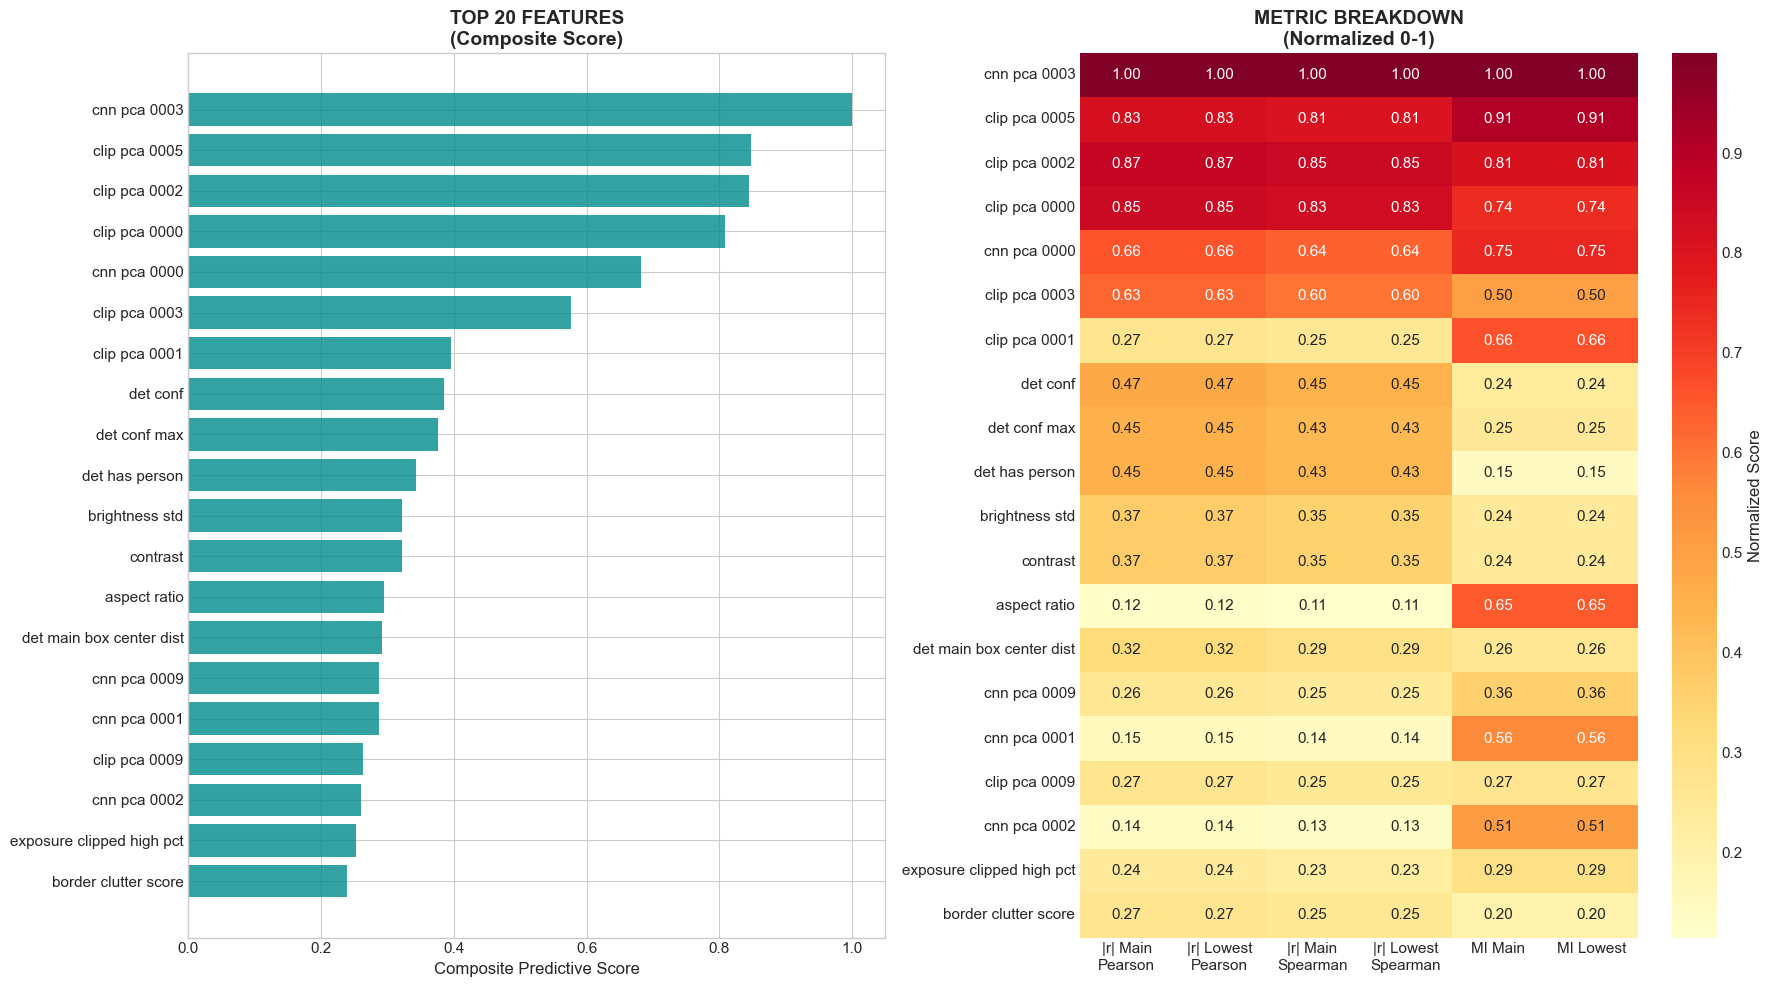

In [29]:
# Visualize Top Features by Composite Score
top_20 = feature_ranking.head(20)

fig, axes = plt.subplots(1, 2, figsize=(18, 10))

# Composite Score Bar Plot
ax1 = axes[0]
y_pos = range(len(top_20))
bars = ax1.barh(y_pos, top_20['composite_score'], color='darkcyan', alpha=0.8)
ax1.set_yticks(y_pos)
ax1.set_yticklabels([s.replace('_mean', '').replace('_', ' ') for s in top_20.index])
ax1.set_xlabel('Composite Predictive Score')
ax1.set_title('TOP 20 FEATURES\n(Composite Score)', fontweight='bold')
ax1.invert_yaxis()

# Heatmap of normalized metrics for top features
ax2 = axes[1]
heatmap_data = top_20[norm_cols].copy()
heatmap_data.columns = ['|r| Main\nPearson', '|r| Lowest\nPearson', 
                        '|r| Main\nSpearman', '|r| Lowest\nSpearman',
                        'MI Main', 'MI Lowest']
sns.heatmap(heatmap_data, annot=True, fmt='.2f', cmap='YlOrRd', 
            ax=ax2, cbar_kws={'label': 'Normalized Score'})
ax2.set_yticklabels([s.replace('_mean', '').replace('_', ' ') for s in top_20.index], rotation=0)
ax2.set_title('METRIC BREAKDOWN\n(Normalized 0-1)', fontweight='bold')

plt.tight_layout()
plt.show()

---
## 13. SUMMARY & KEY FINDINGS

In [32]:
# Generate Summary Statistics for Binary Classification
print("="*90)
print("IMAGE FEATURES EDA SUMMARY - BINARY CLASSIFICATION")
print("="*90)

print("\n📊 DATASET OVERVIEW")
print("-"*50)
print(f"Total products: {len(df):,}")
print(f"Products with image features: {len(df_with_images):,} ({len(df_with_images)/len(df)*100:.1f}%)")

print("\n🎯 BINARY CLASSIFICATION TARGETS")
print("-"*50)
main_counts = df_analysis['has_main_bsr'].value_counts().sort_index()
lowest_counts = df_analysis['has_lowest_bsr'].value_counts().sort_index()

print("TARGET 1 - has_main_bsr (Does product have main BSR rank?):")
print(f"  Class 0 (No BSR):  {main_counts[0]:,} ({main_counts[0]/len(df_analysis)*100:.1f}%)")
print(f"  Class 1 (Has BSR): {main_counts[1]:,} ({main_counts[1]/len(df_analysis)*100:.1f}%)")
print(f"  Class ratio: 1:{main_counts[1]/main_counts[0]:.2f}")

print("\nTARGET 2 - has_lowest_bsr (Does product have any BSR rank?):")
print(f"  Class 0 (No BSR):  {lowest_counts[0]:,} ({lowest_counts[0]/len(df_analysis)*100:.1f}%)")
print(f"  Class 1 (Has BSR): {lowest_counts[1]:,} ({lowest_counts[1]/len(df_analysis)*100:.1f}%)")
print(f"  Class ratio: 1:{lowest_counts[1]/lowest_counts[0]:.2f}")

# Target correlation (how similar are the two binary targets?)
target_agreement = (df_analysis['has_main_bsr'] == df_analysis['has_lowest_bsr']).mean()
print(f"\nTarget agreement rate: {target_agreement*100:.1f}%")

print("\n🏆 TOP 10 MOST PREDICTIVE IMAGE FEATURES")
print("-"*50)
for i, (idx, row) in enumerate(feature_ranking.head(10).iterrows(), 1):
    clean_name = idx.replace('_mean', '').replace('_', ' ')
    print(f"{i:2}. {clean_name:35} (score: {row['composite_score']:.4f})")

print("\n📈 FEATURE GROUP ANALYSIS")
print("-"*50)

# Group the top features by type
def categorize_feature(feat_name):
    if any(q in feat_name for q in ['brightness', 'contrast', 'saturation', 'colorful', 
                                     'sharp', 'blur', 'entropy', 'exposure', 'width', 'height', 'aspect', 'filesize']):
        return 'Quality'
    elif any(c in feat_name for c in ['edge', 'bg_', 'white_bg', 'saliency', 'object_occupancy', 'border', 'dominant_color']):
        return 'Composition'
    elif 'ocr' in feat_name or 'text_overlay' in feat_name:
        return 'OCR'
    elif 'det_' in feat_name:
        return 'Detection'
    elif 'pca' in feat_name:
        return 'Embedding'
    else:
        return 'Other'

top_features_categories = [categorize_feature(f) for f in feature_ranking.head(20).index]
from collections import Counter
cat_counts = Counter(top_features_categories)
print("Feature types in Top 20:")
for cat, count in sorted(cat_counts.items(), key=lambda x: -x[1]):
    print(f"  - {cat}: {count} features")

print("\n💡 KEY INSIGHTS - CLASSIFICATION")
print("-"*50)
print("""
1. CLASSIFICATION TASK: Predicting whether a product has ANY BSR rank is a
   binary classification problem (0 = no BSR, 1 = has BSR).

2. CLASS BALANCE: Check the class distribution - imbalanced classes may require
   techniques like SMOTE, class weights, or stratified sampling.

3. POINT-BISERIAL CORRELATION: For binary targets, point-biserial correlation
   measures the linear relationship between features and class membership.

4. COHEN'S D EFFECT SIZE: Measures how much feature distributions differ between
   classes. |d| > 0.2 is small, > 0.5 is medium, > 0.8 is large effect.

5. MUTUAL INFORMATION: MI for classification captures non-linear discriminative
   power of features for separating the two classes.

6. FEATURE IMPORTANCE: Features that distinguish products WITH BSR from those
   WITHOUT may indicate listing quality or marketplace presence indicators.
""")

print("="*90)
print("END OF CLASSIFICATION EDA")
print("="*90)

IMAGE FEATURES EDA SUMMARY - BINARY CLASSIFICATION

📊 DATASET OVERVIEW
--------------------------------------------------
Total products: 36,879
Products with image features: 36,879 (100.0%)

🎯 BINARY CLASSIFICATION TARGETS
--------------------------------------------------
TARGET 1 - has_main_bsr (Does product have main BSR rank?):
  Class 0 (No BSR):  11,113 (30.1%)
  Class 1 (Has BSR): 25,766 (69.9%)
  Class ratio: 1:2.32

TARGET 2 - has_lowest_bsr (Does product have any BSR rank?):
  Class 0 (No BSR):  11,113 (30.1%)
  Class 1 (Has BSR): 25,766 (69.9%)
  Class ratio: 1:2.32

Target agreement rate: 100.0%

🏆 TOP 10 MOST PREDICTIVE IMAGE FEATURES
--------------------------------------------------
 1. cnn pca 0003                        (score: 1.0000)
 2. clip pca 0005                       (score: 0.8475)
 3. clip pca 0002                       (score: 0.8452)
 4. clip pca 0000                       (score: 0.8081)
 5. cnn pca 0000                        (score: 0.6816)
 6. clip pca

In [33]:
# Export feature ranking for modeling reference
output_cols = ['|r_main_pearson|', '|r_lowest_pearson|', 
               '|r_main_spearman|', '|r_lowest_spearman|',
               'MI_main', 'MI_lowest', 'composite_score']
feature_ranking_export = feature_ranking[output_cols].copy()
feature_ranking_export.index.name = 'feature'
feature_ranking_export.to_csv('image_feature_ranking.csv')
print("Feature ranking exported to: image_feature_ranking.csv")
print(f"Total features ranked: {len(feature_ranking_export)}")

KeyError: "['|r_main_pearson|', '|r_lowest_pearson|', '|r_main_spearman|', '|r_lowest_spearman|'] not in index"

---
## APPENDIX: CATEGORY-LEVEL ANALYSIS
Exploring whether image feature importance varies by product category

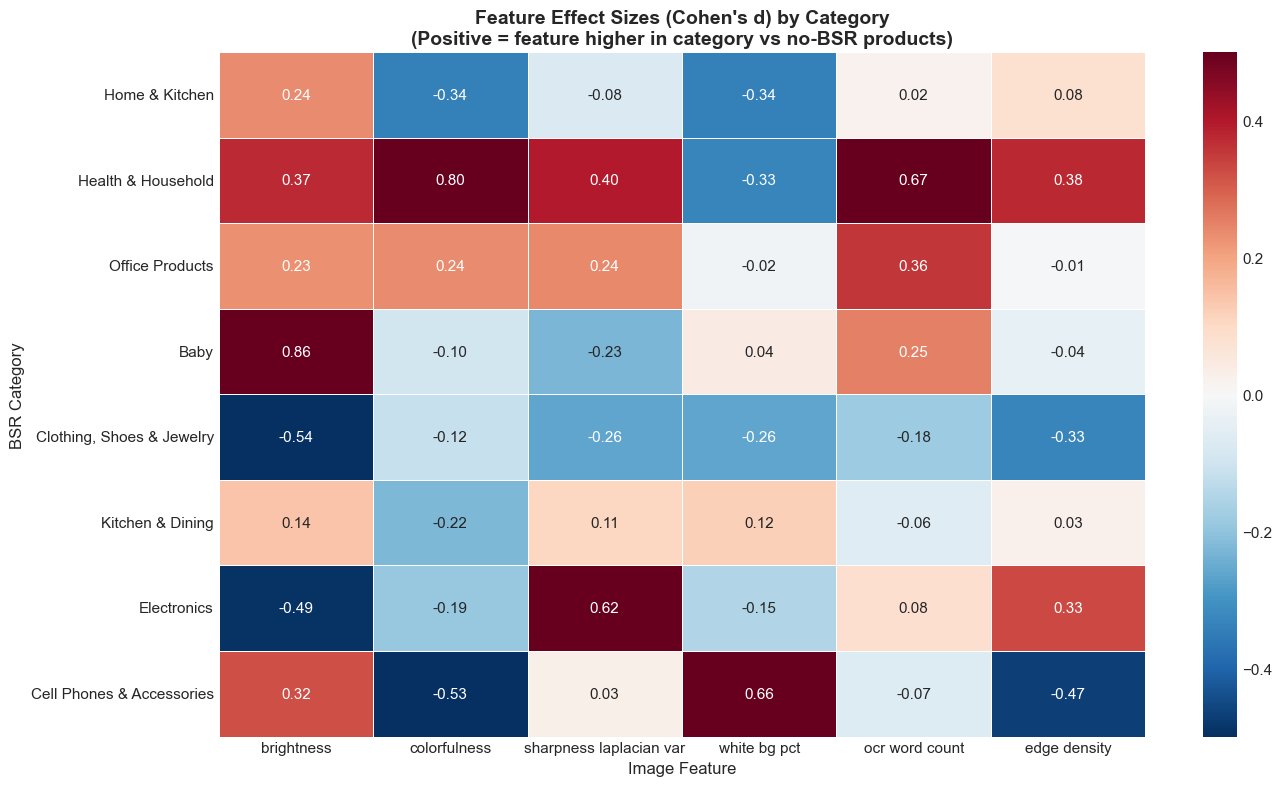


Note: Effect sizes (Cohen's d) measure how much feature values differ between
products in each category vs products without any BSR.
This helps identify which features distinguish BSR-tracked products by category.


In [34]:
# Category-level feature analysis for classification
# Analyze how feature values differ by class (has_main_bsr) within each category

# Get top categories (from products with BSR data)
has_bsr_df = df_analysis[df_analysis['has_main_bsr'] == 1]
top_categories = has_bsr_df['main_bsr_group'].value_counts().head(8).index.tolist()

# Select key features for analysis
key_features = ['brightness_mean_mean', 'colorfulness_mean', 'sharpness_laplacian_var_mean',
                'white_bg_pct_mean', 'ocr_word_count_mean', 'edge_density_mean']
key_features = [f for f in key_features if f in df_analysis.columns]

# Compute Cohen's d effect sizes by category
category_effects = {}
for cat in top_categories:
    # Filter to products that would be in this category (if they had BSR)
    # Note: For products without BSR, we don't know their category
    # So we compare products WITH this category vs all products WITHOUT BSR
    cat_df_has_bsr = df_analysis[(df_analysis['main_bsr_group'] == cat) & (df_analysis['has_main_bsr'] == 1)]
    
    if len(cat_df_has_bsr) < 50:
        continue
    
    cat_effects = {}
    for feat in key_features:
        # Compare feature values for this category vs overall no-BSR products
        data_has_bsr = cat_df_has_bsr[feat].dropna()
        data_no_bsr = df_analysis.loc[df_analysis['has_main_bsr'] == 0, feat].dropna()
        
        if len(data_has_bsr) > 20 and len(data_no_bsr) > 20:
            pooled_std = np.sqrt(((len(data_no_bsr)-1)*data_no_bsr.std()**2 + 
                                 (len(data_has_bsr)-1)*data_has_bsr.std()**2) / 
                                (len(data_no_bsr) + len(data_has_bsr) - 2))
            if pooled_std > 0:
                cohens_d = (data_has_bsr.mean() - data_no_bsr.mean()) / pooled_std
                cat_effects[feat] = cohens_d
    category_effects[cat] = cat_effects

# Convert to DataFrame
cat_effect_df = pd.DataFrame(category_effects).T
cat_effect_df.columns = [c.replace('_mean', '').replace('_', ' ') for c in cat_effect_df.columns]

# Visualize
fig, ax = plt.subplots(figsize=(14, 8))
cat_effect_df_plot = cat_effect_df.copy()
cat_effect_df_plot.index = [str(c)[:30] + '...' if len(str(c)) > 30 else str(c) for c in cat_effect_df_plot.index]
sns.heatmap(cat_effect_df_plot, annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=ax,
            linewidths=0.5, vmin=-0.5, vmax=0.5)
ax.set_title('Feature Effect Sizes (Cohen\'s d) by Category\n(Positive = feature higher in category vs no-BSR products)', 
             fontweight='bold')
ax.set_xlabel('Image Feature')
ax.set_ylabel('BSR Category')
plt.tight_layout()
plt.show()

print("\nNote: Effect sizes (Cohen's d) measure how much feature values differ between")
print("products in each category vs products without any BSR.")
print("This helps identify which features distinguish BSR-tracked products by category.")